# Transformaciones de Variables Económicas y Financieras
## Manipulación de datos con la API del SIE de Banco de México

**Ana Lorena Jiménez Preciado** · Escuela Superior de Economía — IPN · Seminario · 2026

---

### ¿De qué se trata este notebook?

Casi ningún dato económico se usa **como viene**. Antes de estimar cualquier modelo hay que
transformarlo, y esa decisión no es cosmética: **cambia los resultados, cambia la
interpretación y puede invalidar la inferencia**.

El problema es que muchas transformaciones se aplican por costumbre ("siempre le saco logaritmo",
"siempre estandarizo") sin justificación. Este notebook busca lo contrario: para cada
transformación vamos a responder **tres preguntas**:

1. **¿Qué hace?** — la fórmula y qué le ocurre a los momentos de la serie.
2. **¿Por qué la aplico?** — qué problema concreto resuelve.
3. **¿Cómo verifico que funcionó?** — evidencia empírica, no fe.

La última pregunta es la importante. En la §11 sometemos **todas** las transformaciones a la
misma prueba de raíz unitaria y descubrimos que varias de las más populares
—estandarizar, indexar, normalizar— **no hacen absolutamente nada** por la estacionariedad.

---

### Contenido

| § | Tema | Transformación |
|---|------|----------------|
| 1 | Configuración y token | — |
| 2 | Descarga desde el SIE | — |
| 3 | Conocer los datos antes de tocarlos | frecuencia, faltantes, calendario |
| 4 | Cambio de escala | **número índice**, cambio de base, empalme |
| 5 | Tasas de variación | mensual, anual, logarítmica, anualización |
| 6 | Estacionalidad | diferencia estacional, desestacionalización |
| 7 | Precios constantes | **deflactar**, poder adquisitivo, tasa real |
| 8 | Cambio de unidades | **estandarización**, min–max, escalamiento robusto |
| 9 | Escala multiplicativa | logaritmos y rendimientos |
| 10 | Árbol de decisión | ¿cuál uso y por qué? |
| 11 | **Verificación empírica** | ADF sobre todas las transformaciones |
| 12 | Errores comunes y ejercicios | — |

### Series utilizadas (SIE Banxico)

| Clave | Serie | Frecuencia | Unidad |
|-------|-------|-----------|--------|
| `SP1` | INPC general | Mensual | Índice base 2018 = 100 |
| `SF43718` | Tipo de cambio FIX | Diaria | Pesos por dólar |
| `SF61745` | Tasa objetivo de política monetaria | Diaria | % anual |
| `SF60633` | CETES 28 días | Semanal | % anual |
| `SR17692` | IGAE (serie original) | Mensual | Índice base 2018 = 100 |

> **Nota sobre las claves.** El catálogo del SIE cambia con el tiempo. Si una clave deja de
> existir, la descarga de la §2 lo dice con un error claro, y `sie.buscar('texto')` ayuda a
> encontrar la nueva. El catálogo completo está en
> [`/doc/catalogoSeries`](https://www.banxico.org.mx/SieAPIRest/service/v1/doc/catalogoSeries).

---
## 1. Configuración

### 1.1 El token: nunca lo escribas en el código

La API del SIE requiere un token gratuito que puedes generar en
[banxico.org.mx/SieAPIRest/service/v1/token](https://www.banxico.org.mx/SieAPIRest/service/v1/token).

Un token pegado en una celda termina en GitHub, en el PDF que compartes y en el Drive de tus
alumnos. Por eso este notebook no lo contiene: la librería `siebanxico` lo busca fuera del
código. En tu computadora basta ejecutar `siebanxico token` una sola vez en la terminal; en
Colab usamos los **Secrets**:

1. Panel izquierdo, ícono de llave (**Secrets**)
2. **+ Add new secret** → Nombre: `BMX_TOKEN` → Valor: tu token
3. Activa el interruptor **Notebook access**

Si no lo encuentra en ningún lado, la primera descarga te lo pide sin mostrarlo en pantalla.

### 1.2 La librería

Todas las funciones de descarga y transformación viven en `siebanxico`. Aquí solo se importan y
se usan. Si no la tienes instalada (por ejemplo en Colab), ejecuta una vez:

```
!pip install "siebanxico[analisis] @ git+https://github.com/AnaJZP/siebanxico.git"
```

In [1]:
# ─── Librerías ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

import siebanxico as sie

warnings.filterwarnings('ignore')

# ─── Paleta (guinda institucional + acentos) ──────────────────────────────────
C = {
    'guinda' : '#800020',
    'guinda2': '#A0283C',
    'rosa'   : '#D98C9A',
    'teal'   : '#0F7173',
    'ocre'   : '#C9A227',
    'gris'   : '#646464',
    'gris_cl': '#C8C8C8',
    'fondo'  : '#FFFFFF',
}

plt.rcParams.update({
    'figure.figsize'   : (11, 4),
    'figure.dpi'       : 110,
    'figure.facecolor' : C['fondo'],
    'axes.facecolor'   : C['fondo'],
    'axes.edgecolor'   : C['gris_cl'],
    'axes.grid'        : True,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'axes.titlelocation': 'left',
    'axes.labelsize'   : 10,
    'grid.color'       : '#EDEDED',
    'grid.linewidth'   : 0.8,
    'legend.frameon'   : False,
    'font.size'        : 10,
})

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print(f'pandas {pd.__version__} | numpy {np.__version__} | siebanxico {sie.__version__}')

pandas 3.0.6 | numpy 2.5.3 | siebanxico 0.2.0


In [2]:
# ─── Cliente del SIE ──────────────────────────────────────────────────────────
# Aquí no hay token: se toma de los Secrets de Colab, de la variable de entorno
# BANXICO_TOKEN o del archivo guardado con `siebanxico token`.
bmx = sie.Banxico()

---
## 2. Descarga desde el SIE

`descargar` devuelve un `DataFrame` con `DatetimeIndex` y una columna por serie. Tres detalles
que importan, que suelen omitirse y que la librería resuelve por ti:

- **Fechas día/mes/año**: Banxico entrega fechas como `31/12/2024`. Si se deja que pandas
  adivine el orden, interpreta el 12 de marzo donde dice 3 de diciembre y la serie queda
  desordenada en silencio.
- **`'N/E'` → `NaN`**: los no disponibles vienen como texto. Si no se convierten, la columna
  entera queda como `object` y cualquier operación aritmética falla o —peor— se concatena.
- **No mezclar frecuencias en un solo `concat`**: unir una serie diaria con una mensual produce
  una tabla llena de huecos que parece un problema de datos faltantes cuando en realidad es un
  problema de diseño. Por eso descargamos en **dos grupos**.

In [3]:
FECHA_INICIO = '2000-01-01'
FECHA_FIN    = '2026-12-31'

# Se descargan por separado porque tienen frecuencias distintas (ver §3)
SERIES_MENSUALES = {
    'SP1'    : 'INPC',   # Índice Nacional de Precios al Consumidor, base 2018=100
    'SR17692': 'IGAE',   # Indicador Global de la Actividad Económica, serie original
}

SERIES_DIARIAS = {
    'SF43718': 'FIX',     # Tipo de cambio pesos por dólar
    'SF61745': 'Objetivo',# Tasa objetivo de política monetaria (% anual)
    'SF60633': 'Cetes28', # CETES 28 días, tasa de rendimiento (% anual)
}

df_mes_raw = bmx.descargar(SERIES_MENSUALES, FECHA_INICIO, FECHA_FIN)
df_dia_raw = bmx.descargar(SERIES_DIARIAS, FECHA_INICIO, FECHA_FIN)

# El título oficial de cada serie viaja con la tabla: sirve para confirmar qué se bajó
for grupo, tabla in [('Series mensuales', df_mes_raw), ('Series de alta frecuencia', df_dia_raw)]:
    print(f'── {grupo} ' + '─' * (68 - len(grupo)))
    for nombre, ficha in tabla.attrs['series'].items():
        print(f'  {nombre:9s} ({ficha["id"]:8s}) {tabla[nombre].count():6,d} obs | {ficha["titulo"][:62]}')

print(f'\nMensuales : {df_mes_raw.shape[0]:,} filas × {df_mes_raw.shape[1]} columnas')
print(f'Diarias   : {df_dia_raw.shape[0]:,} filas × {df_dia_raw.shape[1]} columnas')
df_mes_raw.tail(3)

── Series mensuales ────────────────────────────────────────────────────
  INPC      (SP1     )    320 obs | IPC Por objeto del gasto Nacional I n d i c e G e n e r a l
  IGAE      (SR17692 )    319 obs | Indicador global de la actividad económica (IGAE) Base 2018 Se
── Series de alta frecuencia ───────────────────────────────────────────
  FIX       (SF43718 )  6,736 obs | Tipo de cambio Pesos por dólar E.U.A. Tipo de cambio para solv
  Objetivo  (SF61745 )  6,739 obs | Tasa objetivo
  Cetes28   (SF60633 )  1,047 obs | Valores gubernamentales, Resultados de la subasta semanal Cete

Mensuales : 320 filas × 2 columnas
Diarias   : 8,769 filas × 3 columnas


,INPC,IGAE
fecha,,
2026-06-01,145.1310,107.3908
2026-07-01,145.1690,109.2101
2026-08-01,145.4620,NaN


---
## 3. Conocer los datos antes de tocarlos

> **Regla del seminario.** Ninguna transformación se justifica si no sabes primero
> qué frecuencia tiene la serie, en qué unidad está medida, qué la genera y dónde tiene huecos.

Esta sección no transforma nada: **diagnostica**. Es el paso que más se omite y el que más
errores previene.

In [4]:
# Resumen mínimo indispensable antes de transformar cualquier serie
print('── Series mensuales ' + '─' * 44)
display(sie.diagnostico(df_mes_raw))

print('── Series de alta frecuencia ' + '─' * 35)
display(sie.diagnostico(df_dia_raw))

── Series mensuales ────────────────────────────────────────────


,obs,inicio,fin,frecuencia,faltantes,min,max,razon_max_min
serie,,,,,,,,
INPC,320,2000-01-01,2026-08-01,Mensual,0,44.9308,145.8310,3.2457
IGAE,319,2000-01-01,2026-07-01,Mensual,0,68.9666,109.2101,1.5835


── Series de alta frecuencia ───────────────────────────────────


,obs,inicio,fin,frecuencia,faltantes,min,max,razon_max_min
serie,,,,,,,,
FIX,6736,2000-01-03,2026-10-06,Diaria,2032,8.9428,25.1185,2.8088
Objetivo,6739,2008-01-21,2026-10-07,Diaria,0,3.0000,11.2500,3.7500
Cetes28,1047,2006-09-19,2026-10-06,Semanal,6024,2.4300,11.4000,4.6914


### 3.1 ¿Por qué la razón máx/mín importa tanto?

Fíjate en la última columna, `razon_max_min`. El INPC va de ~50 a ~145: se multiplicó por **casi tres**.
El FIX va de ~9 a ~21. La tasa objetivo va de 3 a 11.25.

Tres consecuencias inmediatas:

- **No se pueden graficar juntas** en un mismo eje sin que una aplaste a la otra → §4 (índices)
  o §8 (estandarización).
- **Una serie que se triplica en el periodo no puede tener varianza constante** en niveles.
  Eso ya adelanta que habrá que trabajar en tasas o logaritmos → §5 y §9.
- **Una tasa de interés no se transforma igual que un precio.** La tasa objetivo ya está
  acotada y expresada en porcentaje; sacarle "la tasa de crecimiento de la tasa" produce un
  número casi sin interpretación económica. Volveremos a esto en la §10.

### 3.2 Frecuencia: convertir diario → mensual

Para poder combinar el FIX con el INPC hay que llevar todo a una frecuencia común. **La regla
de agregación depende de la naturaleza de la variable**, no del gusto:

| Tipo de variable | Ejemplo | Agregación correcta | Por qué |
|---|---|---|---|
| Variable de **stock** (precio, saldo) | FIX | **último dato** del mes | Es un nivel vigente en un instante |
| Variable de **flujo** (ventas, remesas) | — | **suma** del mes | Se acumula durante el periodo |
| Variable **promedio de referencia** | Tasa objetivo, CETES | **media** del mes | Interesa el nivel prevaleciente |
| **Rendimiento** logarítmico | log-retorno FIX | **suma** del mes | Es aditivo en el tiempo (§9) |

Tomar el promedio mensual de un precio de cierre no es "más suave": es **otra variable**, que
además introduce autocorrelación artificial porque cada promedio comparte información con el
siguiente.

In [5]:
# Agregación a frecuencia mensual, cada variable con su regla
mensual = sie.a_mensual(df_dia_raw, {
    'FIX'     : 'ultimo',     # stock  → último
    'Objetivo': 'promedio',   # nivel  → promedio
    'Cetes28' : 'promedio',   # nivel  → promedio
})

# a_mensual fecha todo al primer día del mes, así que las series se alinean sin desfases
df = pd.concat([sie.a_mensual(df_mes_raw), mensual], axis=1).sort_index()

# Comparación: último vs promedio del mes para el FIX
comp = pd.DataFrame({
    'Último del mes'  : sie.a_mensual(df_dia_raw['FIX'], 'ultimo'),
    'Promedio mensual': sie.a_mensual(df_dia_raw['FIX'], 'promedio'),
}).dropna()
comp['Diferencia'] = comp['Último del mes'] - comp['Promedio mensual']

print('FIX: último del mes vs promedio del mes')
print(f'  Diferencia absoluta media : {comp["Diferencia"].abs().mean():.4f} pesos')
print(f'  Diferencia máxima         : {comp["Diferencia"].abs().max():.4f} pesos '
      f'({comp["Diferencia"].abs().idxmax().date()})')
print(f'  Desv. est. del cambio mensual — último  : '
      f'{comp["Último del mes"].pct_change().std()*100:.3f}%')
print(f'  Desv. est. del cambio mensual — promedio: '
      f'{comp["Promedio mensual"].pct_change().std()*100:.3f}%  ← artificialmente menor')

print(f'\nPanel mensual final: {df.shape[0]} meses × {df.shape[1]} variables')
df.tail(3)

FIX: último del mes vs promedio del mes
  Diferencia absoluta media : 0.1737 pesos
  Diferencia máxima         : 1.2452 pesos (2020-05-01)
  Desv. est. del cambio mensual — último  : 3.117%
  Desv. est. del cambio mensual — promedio: 2.764%  ← artificialmente menor

Panel mensual final: 322 meses × 5 variables


,INPC,IGAE,FIX,Objetivo,Cetes28
fecha,,,,,
2026-08-01,145.4620,NaN,17.0147,6.5000,6.2125
2026-09-01,NaN,NaN,18.0692,6.5000,6.2300
2026-10-01,NaN,NaN,17.9670,6.5000,6.0900


Observa el último par de números: la volatilidad calculada sobre **promedios mensuales** es
sistemáticamente menor que la calculada sobre **cierres**. No es que el mercado sea más
tranquilo; es que promediar es un filtro pasa-bajas que borra variación. Si reportas un VaR
construido sobre promedios mensuales, lo estás **subestimando por construcción**.

---
## 4. Transformación 1 — Números índice

### Qué hace

$$I_t = 100 \times \frac{X_t}{X_{t_0}}$$

Divide toda la serie entre su valor en un periodo base y multiplica por 100. Es una
transformación **afín** (multiplicar por una constante positiva).

### Por qué la aplico

Para **comparar la evolución** de series medidas en unidades distintas. Un índice responde
"¿cuánto ha crecido esto desde el periodo base?" y esa pregunta sí es comparable entre pesos
por dólar, un índice de actividad y un índice de precios.

### Qué NO hace

- **No cambia la forma de la serie**: si tenía tendencia, sigue teniendo tendencia.
- **No la vuelve estacionaria** (lo comprobamos en la §11).
- **No elimina la escala**: la esconde. Un índice de 180 no dice nada sobre el nivel absoluto.

### Cuidado con la base

El periodo base es una **decisión**, y una mal elegida distorsiona la lectura. Si eliges como
base un mes atípico (marzo 2020, por ejemplo), todas las series parecen haber crecido
muchísimo. La convención es usar un año "normal" o el promedio de un año completo.

### 4.0 Desglose de la fórmula

**Paso 1. Elegir el periodo base.** Un periodo $t_0$ cualquiera. Es una decisión, no un dato.

**Paso 2. Formar la razón.** Se divide cada observación entre el valor del periodo base:

$$\frac{X_t}{X_{t_0}}$$

Esta razón es **adimensional**: si $X$ está en pesos, los pesos del numerador se cancelan con
los del denominador. Ese es el truco completo de un número índice. La razón vale exactamente
$1$ en el periodo base, más de $1$ si la serie creció y menos de $1$ si cayó.

**Paso 3. Escalar por 100.** Solo por convención de lectura:

$$I_t = 100 \times \frac{X_t}{X_{t_0}}$$

Un índice de $115$ se lee "15% por encima del nivel base"; uno de $92$, "8% por debajo".

---

**El cambio de base sale de dividir dos índices.** Si ya tienes el índice con base $a$ y lo
quieres con base $b$:

$$I^{(a)}_t = 100\,\frac{X_t}{X_a}
\qquad\text{y}\qquad
I^{(a)}_b = 100\,\frac{X_b}{X_a}$$

Dividiendo el primero entre el segundo, $X_a$ se cancela:

$$\frac{I^{(a)}_t}{I^{(a)}_b} = \frac{X_t}{X_b}
\qquad\Longrightarrow\qquad
\boxed{\;I^{(b)}_t = 100\,\frac{I^{(a)}_t}{I^{(a)}_b}\;}$$

**Consecuencia práctica importante:** para cambiar de base **no necesitas los datos
originales**. Basta el índice publicado. Por eso el cambio de base del INPC se puede hacer con
la serie que descargas, sin pedirle nada al INEGI.

---

**El empalme sale de exigir continuidad.** En el periodo de traslape $t^{*}$ existen dos
valores para el mismo mes: uno en la base vieja y otro en la nueva. Se busca la constante $k$
que los hace coincidir:

$$k \cdot I^{\text{viejo}}_{t^{*}} = I^{\text{nuevo}}_{t^{*}}
\qquad\Longrightarrow\qquad
k = \frac{I^{\text{nuevo}}_{t^{*}}}{I^{\text{viejo}}_{t^{*}}}$$

y se aplica ese mismo $k$ a **todo** el tramo viejo.

### 4.1 Ejemplo numérico paso a paso

Trabajamos con la misma serie de cinco precios en todas las secciones, para que
puedas seguir el hilo de una transformación a otra:

$$P = \{100,\; 108,\; 102,\; 115,\; 110\}
\qquad t = 0, 1, 2, 3, 4$$

**Índice con base en $t_0$** ($X_{t_0} = 100$):

$$I_0 = 100\times\tfrac{100}{100} = 100.0000 \qquad
  I_1 = 100\times\tfrac{108}{100} = 108.0000$$
$$I_2 = 100\times\tfrac{102}{100} = 102.0000 \qquad
  I_3 = 100\times\tfrac{115}{100} = 115.0000 \qquad
  I_4 = 100\times\tfrac{110}{100} = 110.0000$$

> **Cuidado con esta coincidencia.** El índice quedó idéntico al precio **solo porque
> $P_0 = 100$**. No es una propiedad del método; es un accidente de estos números. Si el precio
> inicial fuera 87, el índice no se parecería en nada a la serie original. Conviene hacer notar
> esto en clase porque es fuente frecuente de confusión.

**Cambio de base a $t_2$** (donde $I^{(t_0)}_2 = 102$). Aplicamos
$I^{(t_2)}_t = 100 \cdot I^{(t_0)}_t / 102$:

| $t$ | $P_t$ | $I^{(t_0)}_t$ | Operación | $I^{(t_2)}_t$ |
|---|---|---|---|---|
| 0 | 100 | 100 | $100\times100/102$ | **98.0392** |
| 1 | 108 | 108 | $100\times108/102$ | **105.8824** |
| 2 | 102 | 102 | $100\times102/102$ | **100.0000** |
| 3 | 115 | 115 | $100\times115/102$ | **112.7451** |
| 4 | 110 | 110 | $100\times110/102$ | **107.8431** |

**Lo que cambió y lo que no.** Con base $t_0$, el periodo 3 estaba 15.00% arriba de la base;
con base $t_2$ está 12.7451% arriba. Son lecturas distintas del **mismo hecho**, porque la
referencia cambió. Lo que no cambia es la razón entre dos periodos cualesquiera:

$$\frac{I^{(t_0)}_3}{I^{(t_0)}_1} = \frac{115}{108} = 1.064815
\qquad
\frac{I^{(t_2)}_3}{I^{(t_2)}_1} = \frac{112.7451}{105.8824} = 1.064815$$

Idénticas. **La información relativa se conserva por completo**; solo se movió el punto desde
el cual se mide.

In [6]:
# Verificación del ejemplo a mano (celda autocontenida)
P = pd.Series([100., 108., 102., 115., 110.], index=[f't{i}' for i in range(5)],
              name='Precio')

ej4 = pd.DataFrame({'P_t': P})
ej4['Indice base t0'] = 100 * P / P.iloc[0]
ej4['Indice base t2'] = 100 * ej4['Indice base t0'] / ej4['Indice base t0'].iloc[2]

# El rebase también se puede hacer desde los datos originales: debe dar lo mismo
ej4['Rebase desde P'] = 100 * P / P.iloc[2]

print('Ejemplo numérico de la sección 4.1')
display(ej4.style.format('{:,.4f}'))

# Comprobación 1: el rebase desde el índice y desde los datos coinciden
assert np.allclose(ej4['Indice base t2'], ej4['Rebase desde P'])
print('OK  El cambio de base desde el índice publicado da el mismo resultado')
print('    que desde los datos originales: no se necesita la serie de origen.\n')

# Comprobación 2: las razones entre periodos son invariantes a la base
r_a = ej4['Indice base t0'].iloc[3] / ej4['Indice base t0'].iloc[1]
r_b = ej4['Indice base t2'].iloc[3] / ej4['Indice base t2'].iloc[1]
print(f'Razón t3/t1 con base t0 : {r_a:.10f}')
print(f'Razón t3/t1 con base t2 : {r_b:.10f}')
assert abs(r_a - r_b) < 1e-12
print('OK  Idénticas: cambiar la base no destruye información relativa.')

Ejemplo numérico de la sección 4.1


,P_t,Indice base t0,Indice base t2,Rebase desde P
t0,100.0000,100.0000,98.0392,98.0392
t1,108.0000,108.0000,105.8824,105.8824
t2,102.0000,102.0000,100.0000,100.0000
t3,115.0000,115.0000,112.7451,112.7451
t4,110.0000,110.0000,107.8431,107.8431


OK  El cambio de base desde el índice publicado da el mismo resultado
    que desde los datos originales: no se necesita la serie de origen.

Razón t3/t1 con base t0 : 1.0648148148
Razón t3/t1 con base t2 : 1.0648148148
OK  Idénticas: cambiar la base no destruye información relativa.


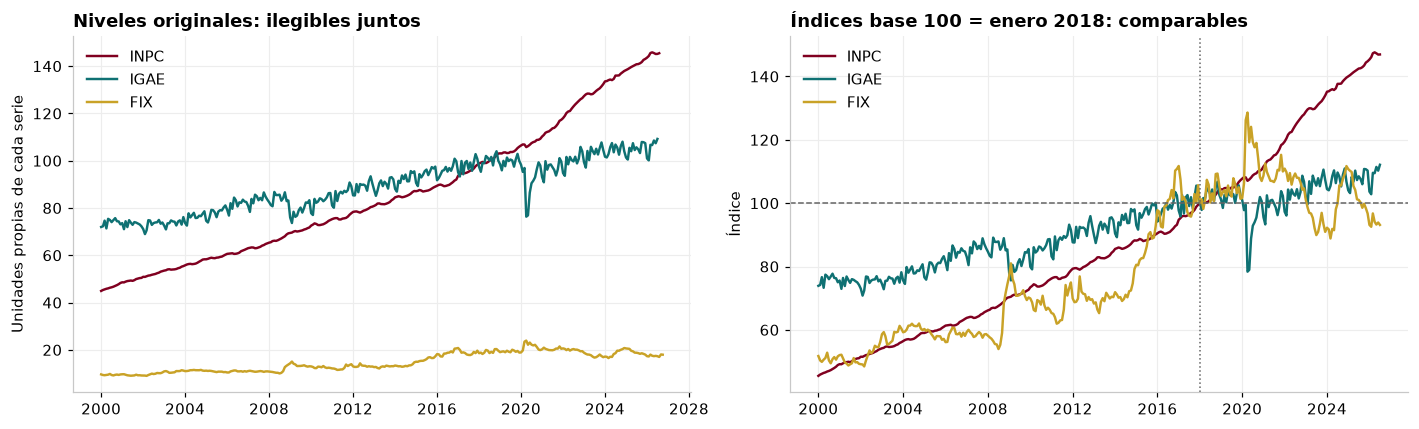

Lectura directa al 2026-07-01 (base ene-2018 = 100):
  INPC :   146.9  →  +46.9% acumulado desde la base
  IGAE :   112.1  →  +12.1% acumulado desde la base
  FIX  :    93.1  →  -6.9% acumulado desde la base


In [7]:
BASE = '2018-01-01'
idx = sie.indice_base(df[['INPC', 'IGAE', 'FIX']], BASE).dropna()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

for col, color in zip(['INPC', 'IGAE', 'FIX'], [C['guinda'], C['teal'], C['ocre']]):
    ax[0].plot(df.index, df[col], color=color, lw=1.6, label=col)
ax[0].set_title('Niveles originales: ilegibles juntos')
ax[0].legend(loc='upper left')
ax[0].set_ylabel('Unidades propias de cada serie')

for col, color in zip(['INPC', 'IGAE', 'FIX'], [C['guinda'], C['teal'], C['ocre']]):
    ax[1].plot(idx.index, idx[col], color=color, lw=1.6, label=col)
ax[1].axhline(100, color=C['gris'], ls='--', lw=1)
ax[1].axvline(pd.Timestamp(BASE), color=C['gris'], ls=':', lw=1)
ax[1].set_title(f'Índices base 100 = enero 2018: comparables')
ax[1].legend(loc='upper left')
ax[1].set_ylabel('Índice')

plt.tight_layout(); plt.show()

ult = idx.iloc[-1]
print(f'Lectura directa al {idx.index[-1].date()} (base ene-2018 = 100):')
for col in idx.columns:
    print(f'  {col:5s}: {ult[col]:7.1f}  →  {"+" if ult[col]>=100 else ""}'
          f'{ult[col]-100:.1f}% acumulado desde la base')

### 4.1 Cambio de base y empalme

Dos operaciones que aparecen constantemente al trabajar con estadística oficial mexicana,
porque el INEGI **cambia la base del INPC** cada varios años (2010, 2018, …) y las series
publicadas quedan partidas.

- **Cambio de base (*rebasing*)**: reexpresar un índice existente en otro periodo base.
  Es solo dividir entre el valor de la nueva base. Como es afín, **no pierde información**.
- **Empalme (*splicing*)**: unir dos tramos con bases distintas. Se escala el tramo viejo por
  el factor de conversión del periodo de traslape.

$$\text{factor} = \frac{I^{\text{nuevo}}_{t^*}}{I^{\text{viejo}}_{t^*}}
\qquad\text{en el periodo de traslape } t^*$$

Abajo lo comprobamos de forma verificable: partimos el INPC en dos tramos con bases distintas,
los empalmamos, y confirmamos que recuperamos exactamente la serie original.

In [8]:
# ─── Cambio de base ───────────────────────────────────────────────────────────
inpc_2018 = sie.indice_base(df['INPC'].dropna(), '2018-01-01')
inpc_2010 = sie.cambiar_base(inpc_2018, '2010-01-01')

print('Mismo INPC, dos bases distintas:')
muestra = pd.DataFrame({'Base ene-2018': inpc_2018, 'Base ene-2010': inpc_2010})
display(muestra.loc[['2010-01-01', '2018-01-01', muestra.index[-1].strftime('%Y-%m-%d')]])

# La razón entre ambos es una constante: prueba de que la transformación es afín
razon = (inpc_2018 / inpc_2010).dropna()
print(f'Razón entre las dos bases — mín: {razon.min():.6f}  máx: {razon.max():.6f}'
      f'  → constante, no se perdió información\n')

# ─── Empalme ──────────────────────────────────────────────────────────────────
TRASLAPE = '2018-01-01'

tramo_viejo = sie.indice_base(df.loc[:'2018-06-01', 'INPC'].dropna(), '2010-01-01')  # base 2010
tramo_nuevo = sie.indice_base(df.loc['2018-01-01':,  'INPC'].dropna(), '2018-01-01')  # base 2018

# El tramo viejo se reescala por este factor; el nuevo queda tal cual
factor = sie.valor_en(tramo_nuevo, TRASLAPE) / sie.valor_en(tramo_viejo, TRASLAPE)
empalmada = sie.empalmar(tramo_viejo, tramo_nuevo, TRASLAPE)

original = sie.indice_base(df['INPC'].dropna(), '2018-01-01')
error = (empalmada - original.reindex(empalmada.index)).abs().max()

print(f'Factor de empalme en {TRASLAPE}: {factor:.6f}')
print(f'Error máximo contra la serie original: {error:.10f}')
print('→ El empalme es exacto: reconstruimos la serie sin perder un solo dato.')

Mismo INPC, dos bases distintas:


,Base ene-2018,Base ene-2010
fecha,,
2010-01-01,73.4370,100.0000
2018-01-01,100.0000,136.1712
2026-08-01,147.2362,200.4933


Razón entre las dos bases — mín: 0.734370  máx: 0.734370  → constante, no se perdió información

Factor de empalme en 2018-01-01: 0.734370
Error máximo contra la serie original: 0.0000000000
→ El empalme es exacto: reconstruimos la serie sin perder un solo dato.


---
## 5. Transformación 2 — Tasas de variación

### Qué hace

| Transformación | Fórmula | Lectura |
|---|---|---|
| Variación periodo a periodo | $\dfrac{X_t - X_{t-1}}{X_{t-1}}$ | "creció x% respecto al mes pasado" |
| Variación anual (interanual) | $\dfrac{X_t - X_{t-12}}{X_{t-12}}$ | "creció x% respecto al mismo mes del año pasado" |
| Variación logarítmica | $\ln X_t - \ln X_{t-1}$ | cambio continuo, aditivo en el tiempo |
| Anualización de una tasa mensual | $(1+r_m)^{12}-1$ | "si este ritmo se mantuviera todo el año" |

### Por qué la aplico

Dos razones distintas que conviene no confundir:

1. **Econométrica**: diferenciar suele inducir estacionariedad. Un precio es $I(1)$; su tasa de
   variación suele ser $I(0)$.
2. **Económica**: la variación es la variable de interés en sí misma. A nadie le importa que el
   INPC valga 145.3; le importa que la inflación anual sea 4.2%.

### El costo

- Se pierden observaciones (1 con $\Delta$, 12 con $\Delta_{12}$).
- Se amplifica el ruido de alta frecuencia.
- **La variación mes a mes de una serie estacional es engañosa** — el tema de la §6.

### 5.0 Desglose de las fórmulas

**De dónde sale $r_t = \ln(1+R_t)$.** Partimos de la definición del rendimiento simple:

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

Sumamos 1 a ambos lados y agrupamos:

$$1 + R_t = 1 + \frac{P_t - P_{t-1}}{P_{t-1}}
          = \frac{P_{t-1} + P_t - P_{t-1}}{P_{t-1}}
          = \frac{P_t}{P_{t-1}}$$

Aplicamos logaritmo natural a ambos lados y usamos $\ln(a/b) = \ln a - \ln b$:

$$\ln(1+R_t) = \ln\!\left(\frac{P_t}{P_{t-1}}\right) = \ln P_t - \ln P_{t-1} = r_t$$

Es una **identidad exacta**, no una aproximación. La aproximación aparece después, al decir
$r_t \approx R_t$, y se justifica con la serie de Taylor de $\ln(1+R)$ alrededor de $R=0$:

$$\ln(1+R) = R - \frac{R^2}{2} + \frac{R^3}{3} - \cdots$$

El primer término omitido es $R^2/2$: **el error crece con el cuadrado** de la tasa.

---

**Por qué los log-rendimientos se suman (aditividad temporal).** Escribimos la suma y
observamos que los términos intermedios se cancelan de dos en dos:

$$\sum_{t=1}^{T} r_t = (\ln P_1 - \ln P_0) + (\ln P_2 - \ln P_1) + \cdots + (\ln P_T - \ln P_{T-1})$$

Todo lo que está en medio aparece una vez con signo $+$ y otra con signo $-$. Sobrevive:

$$\sum_{t=1}^{T} r_t = \ln P_T - \ln P_0 = \ln\!\left(\frac{P_T}{P_0}\right)$$

Esto se llama **suma telescópica** y es la razón de fondo por la que en finanzas se trabaja con
logaritmos. Con rendimientos simples no ocurre nada parecido: $\sum_t R_t$ no es igual a
$P_T/P_0 - 1$ ni se le aproxima cuando hay muchos periodos.

---

**Anualización.** Si una tasa $r_m$ se repitiera $12$ meses **reinvirtiendo**, el capital se
multiplicaría por $(1+r_m)$ doce veces:

$$(1+r_m)\cdot(1+r_m)\cdots(1+r_m) = (1+r_m)^{12}
\qquad\Longrightarrow\qquad
r_{\text{anual}} = (1+r_m)^{12} - 1$$

Multiplicar por 12 en vez de elevar a la 12 ignora el interés compuesto y **subestima**.

**CAGR.** Es la operación inversa. Si el capital pasó de $P_0$ a $P_T$ en $T$ periodos a una
tasa constante $g$, entonces $P_T = P_0(1+g)^T$. Despejando:

$$g = \left(\frac{P_T}{P_0}\right)^{1/T} - 1$$

**Volatilidad.** Si los rendimientos son independientes y con varianza constante $\sigma^2$,
la varianza de la suma de $h$ de ellos es la suma de las varianzas:

$$\operatorname{Var}\!\left(\sum_{i=1}^{h} r_i\right) = h\,\sigma^2
\qquad\Longrightarrow\qquad
\sigma_h = \sigma\sqrt{h}$$

De ahí el $\sqrt{252}$. **Los dos supuestos —independencia y varianza constante— son
justamente los que la Parte III del curso demuestra que son falsos** en datos financieros. La
regla se usa igual, pero sabiendo que es una aproximación.

### 5.1 Ejemplo numérico paso a paso

Trabajamos con la misma serie de cinco precios en todas las secciones, para que
puedas seguir el hilo de una transformación a otra:

$$P = \{100,\; 108,\; 102,\; 115,\; 110\}
\qquad t = 0, 1, 2, 3, 4$$

| $t$ | $P_t$ | $R_t = \frac{P_t-P_{t-1}}{P_{t-1}}$ | $R_t$ (%) | $r_t = \ln(P_t/P_{t-1})$ | $r_t$ (%) |
|---|---|---|---|---|---|
| 1 | 108 | $8/100$ | $+8.0000$ | $\ln(1.080000)$ | $+7.6961$ |
| 2 | 102 | $-6/108$ | $-5.5556$ | $\ln(0.944444)$ | $-5.7158$ |
| 3 | 115 | $13/102$ | $+12.7451$ | $\ln(1.127451)$ | $+11.9959$ |
| 4 | 110 | $-5/115$ | $-4.3478$ | $\ln(0.956522)$ | $-4.4452$ |

**Ahora sumamos las dos columnas y comparamos con la verdad.**

El rendimiento total verdadero del periodo es $110/100 - 1 = 10.0000\%$, y su versión
logarítmica es $\ln(110/100) = 9.5310\%$.

$$\sum_t r_t = 7.6961 - 5.7158 + 11.9959 - 4.4452 = 9.5310\%
\;=\; \ln(P_4/P_0) \qquad \text{(exacto)}$$

$$\sum_t R_t = 8.0000 - 5.5556 + 12.7451 - 4.3478 = 10.8417\%
\;\neq\; 10.0000\% \qquad \text{(sobreestima en 0.8417 pp)}$$

**Esa diferencia de 0.84 puntos es en apenas cuatro periodos.** Con 252 días de rendimientos
diarios el error se vuelve enorme. Si alguna vez ves un reporte que "suma los rendimientos
porcentuales del año", está mal calculado.

---

**Anualización, con números.** Una tasa mensual de $0.5\%$:

$$(1.005)^{12} - 1 = 1.061678 - 1 = 6.1678\%
\qquad\text{contra}\qquad 12 \times 0.5\% = 6.0000\%$$

La diferencia de $0.1678$ pp es el interés compuesto. Parece poco, pero con tasas altas
crece rápido: con $2\%$ mensual, $(1.02)^{12}-1 = 26.82\%$ contra el $24\%$ ingenuo.

**Volatilidad.** Una desviación estándar diaria de $0.8\%$:

$$\sigma_{\text{anual}} = 0.8 \times \sqrt{252} = 0.8 \times 15.8745 = 12.6996\%$$

**CAGR de la serie de juguete.** Cuatro periodos, de 100 a 110:

$$g = (110/100)^{1/4} - 1 = 1.024114 - 1 = 2.4114\%\ \text{por periodo}$$

Compruébalo: $100 \times (1.024114)^4 = 110.00$. Nota que $2.4114\% \neq 10\%/4 = 2.5\%$;
otra vez, la diferencia es el efecto compuesto.

In [9]:
# Verificación del ejemplo a mano (celda autocontenida)
P = pd.Series([100., 108., 102., 115., 110.])

ej5 = pd.DataFrame({
    'P_t'      : P,
    'R_t (%)'  : P.pct_change() * 100,
    'r_t (%)'  : np.log(P).diff() * 100,
})
ej5['Error (pp)'] = ej5['R_t (%)'] - ej5['r_t (%)']
print('Ejemplo numérico de la sección 5.1')
display(ej5.style.format('{:,.4f}', na_rep=''))

suma_r    = ej5['r_t (%)'].sum()
suma_R    = ej5['R_t (%)'].sum()
verdad_log = np.log(P.iloc[-1] / P.iloc[0]) * 100
verdad_sim = (P.iloc[-1] / P.iloc[0] - 1) * 100

print(f'{"Suma de log-rendimientos":32s}: {suma_r:9.4f} %')
print(f'{"ln(P4/P0)":32s}: {verdad_log:9.4f} %   <- coinciden')
print(f'{"Suma de rendimientos simples":32s}: {suma_R:9.4f} %')
print(f'{"Rendimiento total verdadero":32s}: {verdad_sim:9.4f} %   <- NO coinciden')
print(f'{"Error de sumar simples":32s}: {suma_R - verdad_sim:9.4f} pp\n')

assert abs(suma_r - verdad_log) < 1e-10, 'la suma telescópica debe ser exacta'
print('OK  La aditividad temporal del log-rendimiento se cumple exactamente.\n')

# Anualización, volatilidad y CAGR
r_m = 0.005
print(f'Tasa mensual 0.5%  ->  compuesta: {((1+r_m)**12 - 1)*100:.4f}%   '
      f'ingenua: {12*r_m*100:.4f}%   diferencia: {((1+r_m)**12 - 1 - 12*r_m)*100:.4f} pp')
r_m2 = 0.02
print(f'Tasa mensual 2.0%  ->  compuesta: {((1+r_m2)**12 - 1)*100:.4f}%  '
      f'ingenua: {12*r_m2*100:.4f}%  diferencia: {((1+r_m2)**12 - 1 - 12*r_m2)*100:.4f} pp')

sigma_d = 0.8
print(f'\nVolatilidad diaria 0.8% -> anual: {sigma_d*np.sqrt(252):.4f}%  '
      f'(factor sqrt(252) = {np.sqrt(252):.4f})')

T = len(P) - 1
g = (P.iloc[-1] / P.iloc[0])**(1/T) - 1
print(f'\nCAGR sobre {T} periodos: {g*100:.4f}% por periodo')
print(f'Comprobación: 100 * (1 + {g:.6f})^{T} = {100*(1+g)**T:.4f}')
assert abs(100*(1+g)**T - P.iloc[-1]) < 1e-9
print(f'Promedio aritmético ingenuo: {verdad_sim/T:.4f}% -> sobreestima')

Ejemplo numérico de la sección 5.1


,P_t,R_t (%),r_t (%),Error (pp)
0,100.0000,,,
1,108.0000,8.0000,7.6961,0.3039
2,102.0000,-5.5556,-5.7158,0.1603
3,115.0000,12.7451,11.9959,0.7492
4,110.0000,-4.3478,-4.4452,0.0974


Suma de log-rendimientos        :    9.5310 %
ln(P4/P0)                       :    9.5310 %   <- coinciden
Suma de rendimientos simples    :   10.8417 %
Rendimiento total verdadero     :   10.0000 %   <- NO coinciden
Error de sumar simples          :    0.8417 pp

OK  La aditividad temporal del log-rendimiento se cumple exactamente.

Tasa mensual 0.5%  ->  compuesta: 6.1678%   ingenua: 6.0000%   diferencia: 0.1678 pp
Tasa mensual 2.0%  ->  compuesta: 26.8242%  ingenua: 24.0000%  diferencia: 2.8242 pp

Volatilidad diaria 0.8% -> anual: 12.6996%  (factor sqrt(252) = 15.8745)

CAGR sobre 4 periodos: 2.4114% por periodo
Comprobación: 100 * (1 + 0.024114)^4 = 110.0000
Promedio aritmético ingenuo: 2.5000% -> sobreestima


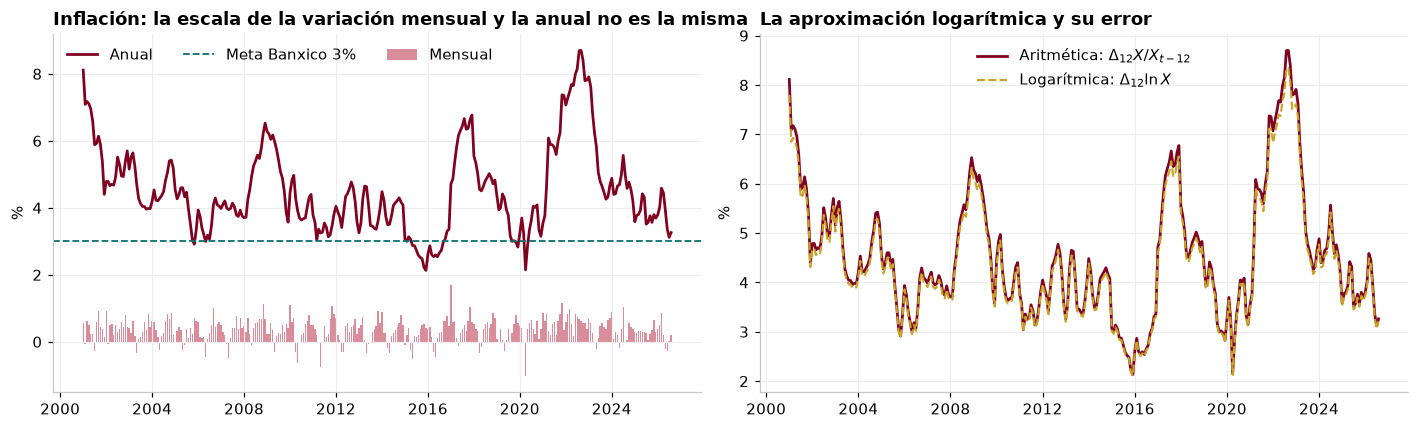

Diferencia entre la tasa aritmética y la logarítmica (puntos porcentuales):
  Media  : 0.1066 pp
  Máxima : 0.3578 pp  (cuando la inflación fue 8.70%)


,Mensual (%),Anual (%),Anual log (%),Mensual anualizada (%),Error aprox. (pp)
fecha,,,,,
2026-03-01,0.8572,4.5868,4.4847,10.7855,0.1021
2026-04-01,0.1972,4.4485,4.3524,2.3921,0.0961
2026-05-01,-0.2085,3.9389,3.8634,-2.4730,0.0756
2026-06-01,-0.2721,3.3660,3.3106,-3.2169,0.0554
2026-07-01,0.0262,3.1176,3.0700,0.3147,0.0476
2026-08-01,0.2018,3.2619,3.2099,2.4491,0.0521


In [10]:
inpc = df['INPC'].dropna()

tasas = pd.DataFrame({
    'Mensual (%)'          : inpc.pct_change() * 100,
    'Anual (%)'            : inpc.pct_change(12) * 100,
    'Anual log (%)'        : np.log(inpc).diff(12) * 100,
    'Mensual anualizada (%)': ((1 + inpc.pct_change())**12 - 1) * 100,
}).dropna()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].bar(tasas.index, tasas['Mensual (%)'], width=22,
          color=C['rosa'], label='Mensual')
ax[0].plot(tasas.index, tasas['Anual (%)'], color=C['guinda'], lw=1.8, label='Anual')
ax[0].axhline(3, color=C['teal'], ls='--', lw=1.2, label='Meta Banxico 3%')
ax[0].set_title('Inflación: la escala de la variación mensual y la anual no es la misma')
ax[0].set_ylabel('%'); ax[0].legend(ncols=3)

ax[1].plot(tasas.index, tasas['Anual (%)'], color=C['guinda'], lw=1.8,
           label='Aritmética: $\\Delta_{12}X/X_{t-12}$')
ax[1].plot(tasas.index, tasas['Anual log (%)'], color=C['ocre'], lw=1.4, ls='--',
           label='Logarítmica: $\\Delta_{12}\\ln X$')
ax[1].set_title('La aproximación logarítmica y su error')
ax[1].set_ylabel('%'); ax[1].legend()

plt.tight_layout(); plt.show()

tasas['Error aprox. (pp)'] = tasas['Anual (%)'] - tasas['Anual log (%)']
print('Diferencia entre la tasa aritmética y la logarítmica (puntos porcentuales):')
print(f'  Media  : {tasas["Error aprox. (pp)"].mean():.4f} pp')
print(f'  Máxima : {tasas["Error aprox. (pp)"].max():.4f} pp  '
      f'(cuando la inflación fue {tasas.loc[tasas["Error aprox. (pp)"].idxmax(), "Anual (%)"]:.2f}%)')
display(tasas.tail(6))

### 5.1 ¿Cuándo puedo usar $\Delta \ln X$ como si fuera el cambio porcentual?

La relación exacta es $\ln(1+R) \approx R - R^2/2 + R^3/3 - \dots$, así que el error crece con
el **cuadrado** de la tasa. La tabla de abajo lo cuantifica: con inflaciones de un dígito la
aproximación es excelente; con variaciones grandes (una depreciación cambiaria del 30%, un
rendimiento accionario del 50%) deja de serlo y reportar una en lugar de la otra es un error.

**Regla práctica:** por debajo de ±10% son intercambiables para fines expositivos; por encima,
hay que decir explícitamente cuál se está usando.

In [11]:
R = np.array([0.001, 0.01, 0.05, 0.10, 0.20, 0.30, 0.50, 1.00])
tabla_aprox = pd.DataFrame({
    'Cambio simple R (%)'   : R * 100,
    'Cambio log r (%)'      : np.log1p(R) * 100,
    'Error absoluto (pp)'   : (R - np.log1p(R)) * 100,
    'Error relativo (%)'    : (R - np.log1p(R)) / R * 100,
})
print('Qué tan buena es la aproximación  r = ln(1+R) ≈ R')
display(tabla_aprox.style.format('{:,.4f}').hide(axis='index'))

# Caso concreto con datos reales: el peor mes del FIX
fix = df['FIX'].dropna()
peor = fix.pct_change().abs().idxmax()
r_s = fix.pct_change().loc[peor] * 100
r_l = np.log(fix).diff().loc[peor] * 100
print(f'\nMes de mayor movimiento del FIX: {peor.strftime("%B %Y")}')
print(f'  Variación simple      : {r_s:+.2f}%')
print(f'  Variación logarítmica : {r_l:+.2f}%')
print(f'  Diferencia            : {abs(r_s - r_l):.2f} pp — nada despreciable en un reporte')

Qué tan buena es la aproximación  r = ln(1+R) ≈ R


Cambio simple R (%),Cambio log r (%),Error absoluto (pp),Error relativo (%)
0.1000,0.1000,0.0000,0.0500
1.0000,0.9950,0.0050,0.4967
5.0000,4.8790,0.1210,2.4197
10.0000,9.5310,0.4690,4.6898
20.0000,18.2322,1.7678,8.8392
30.0000,26.2364,3.7636,12.5452
50.0000,40.5465,9.4535,18.9070
100.0000,69.3147,30.6853,30.6853



Mes de mayor movimiento del FIX: March 2020
  Variación simple      : +18.75%
  Variación logarítmica : +17.19%
  Diferencia            : 1.57 pp — nada despreciable en un reporte


---
## 6. Transformación 3 — Estacionalidad

### El problema

El IGAE (serie original) sube todos los diciembres y cae todos los eneros. Si comparas
enero contra diciembre concluyes que "la economía se desplomó". No se desplomó: **es enero**.

Confundir el patrón estacional con la señal económica es probablemente el error más frecuente
al leer estadística oficial en los medios.

### Tres formas de tratarlo

| Método | Fórmula | Ventaja | Costo |
|---|---|---|---|
| **Variación anual** | $X_t/X_{t-12}-1$ | Trivial de calcular; compara "manzanas con manzanas" | Pierde 12 obs; reacciona con rezago a los quiebres |
| **Diferencia estacional** | $\Delta_{12} X_t = X_t - X_{t-12}$ | Elimina el patrón fijo; útil para SARIMA | Introduce estructura MA en el error |
| **Desestacionalizar** | $X_t / S_t$ (multiplicativo) | Conserva todas las observaciones y permite leer mes a mes | El factor $S_t$ es una **estimación**, y se revisa |

> **Advertencia importante.** Nunca desestacionalices una serie **que ya viene desestacionalizada**
> por la fuente. Y nunca compares una serie original contra una ajustada: no son la misma
> variable.

### 6.0 Desglose: por qué la variación anual elimina la estacionalidad

Supongamos que la serie se descompone de forma **multiplicativa** en tendencia, factor
estacional e irregular:

$$X_t = T_t \cdot S_t \cdot I_t$$

donde $S_t$ es el factor propio del mes (por ejemplo $S_{\text{dic}} = 1.12$ significa
"diciembre está 12% por encima de lo normal").

Formamos la razón interanual, es decir, dividimos entre el **mismo mes** del año anterior:

$$\frac{X_t}{X_{t-12}}
= \frac{T_t \cdot S_t \cdot I_t}{T_{t-12}\cdot S_{t-12}\cdot I_{t-12}}
= \frac{T_t}{T_{t-12}} \cdot \underbrace{\frac{S_t}{S_{t-12}}}_{=\,1}
  \cdot \frac{I_t}{I_{t-12}}$$

El cociente central vale exactamente 1 **porque $t$ y $t-12$ son el mismo mes calendario** y,
por construcción, tienen el mismo factor estacional: $S_t = S_{t-12}$.

$$\boxed{\;\frac{X_t}{X_{t-12}} = \frac{T_t}{T_{t-12}}\cdot\frac{I_t}{I_{t-12}}\;}$$

La estacionalidad **se cancela sola**. Queda tendencia por irregular, que es justamente lo que
queremos leer.

**Los dos supuestos que esto exige** —y que conviene señalar en clase—:

1. Que el patrón estacional sea **estable** ($S_t = S_{t-12}$). Si la estacionalidad cambia con
   el tiempo, la cancelación es solo aproximada.
2. Que no haya efectos de calendario móviles: Semana Santa cae en marzo o en abril según el
   año, y ahí $S_t \neq S_{t-12}$ aunque el mes sea el mismo. Por eso las agencias estadísticas
   aplican un ajuste adicional por "efecto Semana Santa".

**El costo:** se pierden 12 observaciones y la serie resultante reacciona con rezago, porque
cada dato compara contra algo que ocurrió un año antes.

### 6.1 Ejemplo numérico paso a paso

Un indicador de actividad con estacionalidad marcada: diciembre alto, enero bajo.

| Mes | Valor |
|---|---|
| Dic 2023 | 120 |
| Ene 2024 | 100 |
| Dic 2024 | 126 |
| Ene 2025 | 105 |

**Lectura 1: variación mes contra mes.**

$$\frac{100 - 120}{120} = -16.6667\%
\qquad\qquad
\frac{105 - 126}{126} = -16.6667\%$$

Un titular diría: *"la actividad se desplomó 16.7% en enero"*. Y lo diría **dos años
seguidos, con exactamente la misma cifra**. Esa repetición es la señal de alarma: no es un
desplome, es el calendario.

**Lectura 2: variación anual (mismo mes contra mismo mes).**

$$\text{Enero: } \frac{105-100}{100} = +5.0000\%
\qquad\qquad
\text{Diciembre: } \frac{126-120}{120} = +5.0000\%$$

La economía creció 5%, de manera consistente, medida en enero o en diciembre. **Esta es la
señal verdadera.** Nota cómo la fórmula del desglose se cumple: el factor estacional de enero
se canceló contra sí mismo, y el de diciembre también.

**Lectura 3: recuperar el factor estacional.** Enero vale sistemáticamente
$100/120 = 0.8333$ de lo que vale el diciembre previo. Es decir, enero está alrededor de
$16.67\%$ por debajo por razones puramente de calendario. Desestacionalizar consiste,
en esencia, en dividir cada mes entre su factor para que todos queden comparables entre sí.

> **La moraleja operativa:** nunca reportes la variación mes a mes de una serie original.
> O usas la variación anual, o usas la serie desestacionalizada; pero no mezcles.

In [12]:
# Verificación del ejemplo a mano (celda autocontenida)
ej6 = pd.Series({'Dic 2023': 120., 'Ene 2024': 100.,
                 'Dic 2024': 126., 'Ene 2025': 105.})
print('Ejemplo numérico de la sección 6.1\n')
print(ej6.to_string(), '\n')

mm_2024 = (ej6['Ene 2024'] / ej6['Dic 2023'] - 1) * 100
mm_2025 = (ej6['Ene 2025'] / ej6['Dic 2024'] - 1) * 100
print('Variación mes contra mes:')
print(f'  Ene 2024 vs Dic 2023 : {mm_2024:+8.4f} %')
print(f'  Ene 2025 vs Dic 2024 : {mm_2025:+8.4f} %')
print('  -> Idénticas dos años seguidos: es calendario, no economía.\n')

aa_ene = (ej6['Ene 2025'] / ej6['Ene 2024'] - 1) * 100
aa_dic = (ej6['Dic 2024'] / ej6['Dic 2023'] - 1) * 100
print('Variación anual (mismo mes contra mismo mes):')
print(f'  Ene 2025 vs Ene 2024 : {aa_ene:+8.4f} %')
print(f'  Dic 2024 vs Dic 2023 : {aa_dic:+8.4f} %')
print('  -> Coinciden: esa es la señal económica real.\n')

assert abs(mm_2024 - mm_2025) < 1e-9, 'el patrón estacional es idéntico'
assert abs(aa_ene - aa_dic) < 1e-9, 'la tendencia es la misma medida en cualquier mes'

factor = ej6['Ene 2024'] / ej6['Dic 2023']
print(f'Factor estacional implícito enero/diciembre: {factor:.4f}')
print(f'  Enero está {(1-factor)*100:.2f}% por debajo de diciembre por puro calendario.')
print(f'\nSi "desestacionalizamos" enero dividiendo entre ese factor:')
print(f'  Ene 2024 ajustado: {ej6["Ene 2024"]/factor:.2f}  (comparable con Dic 2023 = 120)')
print(f'  Ene 2025 ajustado: {ej6["Ene 2025"]/factor:.2f}  (comparable con Dic 2024 = 126)')

Ejemplo numérico de la sección 6.1

Dic 2023   120.0000
Ene 2024   100.0000
Dic 2024   126.0000
Ene 2025   105.0000 

Variación mes contra mes:
  Ene 2024 vs Dic 2023 : -16.6667 %
  Ene 2025 vs Dic 2024 : -16.6667 %
  -> Idénticas dos años seguidos: es calendario, no economía.

Variación anual (mismo mes contra mismo mes):
  Ene 2025 vs Ene 2024 :  +5.0000 %
  Dic 2024 vs Dic 2023 :  +5.0000 %
  -> Coinciden: esa es la señal económica real.

Factor estacional implícito enero/diciembre: 0.8333
  Enero está 16.67% por debajo de diciembre por puro calendario.

Si "desestacionalizamos" enero dividiendo entre ese factor:
  Ene 2024 ajustado: 120.00  (comparable con Dic 2023 = 120)
  Ene 2025 ajustado: 126.00  (comparable con Dic 2024 = 126)


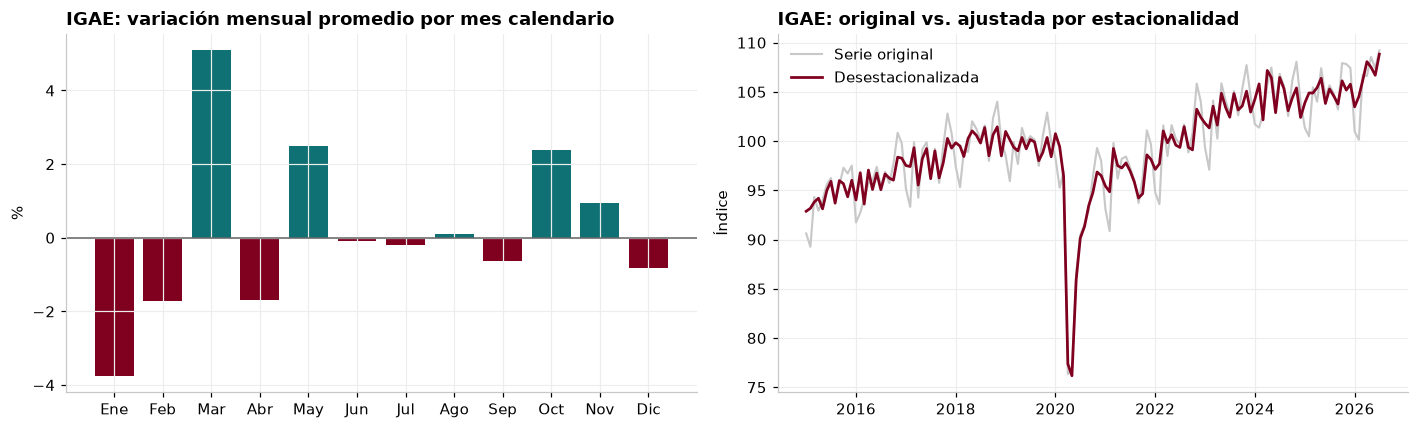

Mes con mayor factor estacional: Mar (+5.09% promedio)
Mes con menor factor estacional: Ene (-3.75% promedio)

Amplitud del factor estacional: 7.0% entre el mes más alto y el más bajo
→ Cualquier lectura mes-contra-mes de la serie ORIGINAL está contaminada por esto.


In [13]:
igae = df['IGAE'].dropna()

# ─── Evidencia de que la estacionalidad existe: promedio por mes calendario ────
var_mensual = igae.pct_change().dropna() * 100
perfil = var_mensual.groupby(var_mensual.index.month).mean()
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

colores = [C['teal'] if v >= 0 else C['guinda'] for v in perfil.values]
ax[0].bar(range(1, 13), perfil.values, color=colores)
ax[0].axhline(0, color=C['gris'], lw=1)
ax[0].set_xticks(range(1, 13)); ax[0].set_xticklabels(meses)
ax[0].set_title('IGAE: variación mensual promedio por mes calendario')
ax[0].set_ylabel('%')

# ─── Descomposición ───────────────────────────────────────────────────────────
igae_sa = sie.desestacionalizar(igae, modelo='multiplicativo')   # X_t / S_t
factor_estacional = igae / igae_sa                                # S_t
ventana = igae.index >= '2015-01-01'

ax[1].plot(igae[ventana].index, igae[ventana], color=C['gris_cl'], lw=1.4,
           label='Serie original')
ax[1].plot(igae_sa[ventana].index, igae_sa[ventana], color=C['guinda'], lw=1.8,
           label='Desestacionalizada')
ax[1].set_title('IGAE: original vs. ajustada por estacionalidad')
ax[1].set_ylabel('Índice'); ax[1].legend()

plt.tight_layout(); plt.show()

print(f'Mes con mayor factor estacional: {meses[perfil.idxmax()-1]} '
      f'({perfil.max():+.2f}% promedio)')
print(f'Mes con menor factor estacional: {meses[perfil.idxmin()-1]} '
      f'({perfil.min():+.2f}% promedio)')
print(f'\nAmplitud del factor estacional: '
      f'{(factor_estacional.max()/factor_estacional.min() - 1)*100:.1f}% entre el mes más alto y el más bajo')
print('→ Cualquier lectura mes-contra-mes de la serie ORIGINAL está contaminada por esto.')

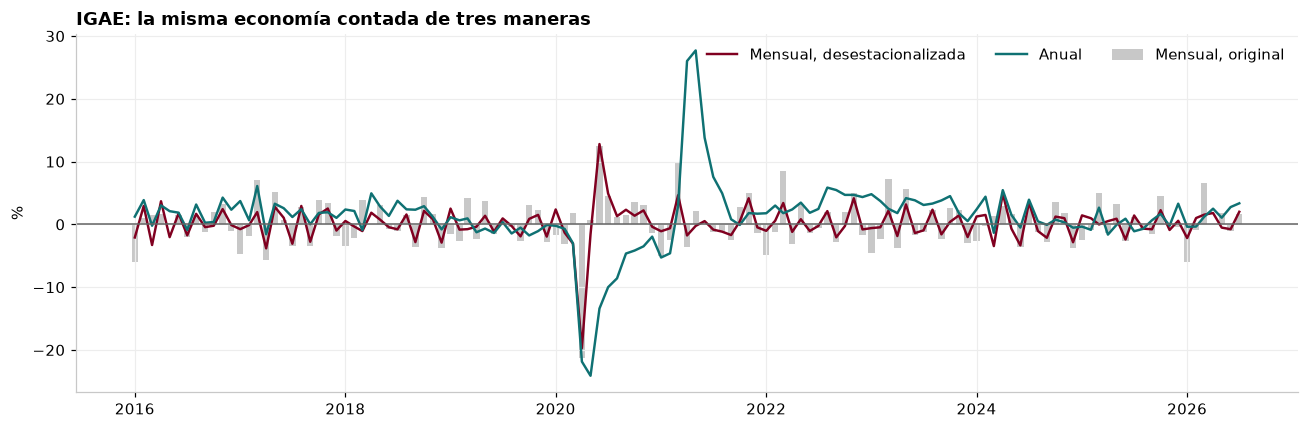

Volatilidad (desv. est.) de cada lectura:
  Var. mensual, serie original (%)             :   3.35 pp
  Var. mensual, desestacionalizada (%)         :   2.49 pp
  Var. anual (%)                               :   4.31 pp

→ La variación mensual de la serie original es la más volátil, y buena parte de esa
  volatilidad es puramente estacional: NO es información económica.


In [14]:
# Las tres lecturas del mismo dato, lado a lado
comparacion = pd.DataFrame({
    'Var. mensual, serie original (%)'          : igae.pct_change() * 100,
    'Var. mensual, desestacionalizada (%)'      : igae_sa.pct_change() * 100,
    'Var. anual (%)'                            : igae.pct_change(12) * 100,
}).dropna()

fig, ax = plt.subplots(figsize=(12, 4))
v = comparacion.index >= '2016-01-01'
ax.bar(comparacion[v].index, comparacion.loc[v, 'Var. mensual, serie original (%)'],
       width=22, color=C['gris_cl'], label='Mensual, original')
ax.plot(comparacion[v].index, comparacion.loc[v, 'Var. mensual, desestacionalizada (%)'],
        color=C['guinda'], lw=1.6, label='Mensual, desestacionalizada')
ax.plot(comparacion[v].index, comparacion.loc[v, 'Var. anual (%)'],
        color=C['teal'], lw=1.6, label='Anual')
ax.axhline(0, color=C['gris'], lw=1)
ax.set_title('IGAE: la misma economía contada de tres maneras')
ax.set_ylabel('%'); ax.legend(ncols=3)
plt.tight_layout(); plt.show()

print('Volatilidad (desv. est.) de cada lectura:')
for col in comparacion.columns:
    print(f'  {col:45s}: {comparacion[col].std():6.2f} pp')
print('\n→ La variación mensual de la serie original es la más volátil, y buena parte de esa')
print('  volatilidad es puramente estacional: NO es información económica.')

---
## 7. Transformación 4 — Deflactar (precios constantes)

### Qué hace

$$X^{\text{real}}_t = \frac{X^{\text{nominal}}_t}{\text{INPC}_t / 100}$$

Expresa una serie monetaria en pesos de **poder adquisitivo constante** (los del año base del
índice de precios, aquí 2018).

### Por qué la aplico

Porque comparar pesos de 2005 con pesos de 2025 es comparar dos unidades distintas que
casualmente se llaman igual. Una serie nominal creciente puede estar **cayendo** en términos
reales, y esa es la variable económicamente relevante.

### Tres aplicaciones distintas

1. **Poder adquisitivo de un monto puntual**: ¿cuánto valen hoy $1,000 de 2010?
2. **Serie nominal → serie real**: deflactar toda la trayectoria.
3. **Tasa de interés nominal → real** (ecuación de Fisher): el caso más relevante en finanzas.

### 7.0 Desglose de las fórmulas

**Qué significa realmente dividir entre el índice de precios.** Un monto nominal es, en el
fondo, un precio multiplicado por una cantidad:

$$X^{\text{nom}}_t = P_t \cdot q_t$$

Si el índice de precios está construido como $\text{INPC}_t = 100 \cdot P_t / P_{t_0}$
(precios del periodo actual respecto a los del año base), entonces:

$$\frac{X^{\text{nom}}_t}{\text{INPC}_t/100}
= \frac{P_t \cdot q_t}{P_t/P_{t_0}}
= q_t \cdot P_{t_0}$$

$$\boxed{\;X^{\text{real}}_t = q_t \cdot P_{t_0}\;}$$

Es decir: **la serie real es la cantidad valuada a precios del año base**. No es "quitarle la
inflación" en un sentido vago; es reexpresar todo en una unidad fija —el poder de compra de
2018— para que los números de años distintos sean sumables y comparables.

Por eso el año base aparece siempre en el reporte: *"millones de pesos de 2018"*. Una serie
real sin año base declarado es ininterpretable.

---

**Convertir un monto entre dos fechas.** Se encadenan dos conversiones: de la fecha origen al
año base, y del año base a la fecha destino. Los factores se multiplican y el año base se
cancela:

$$M_{\text{destino}} = M_{\text{origen}} \times
\frac{\text{INPC}_{\text{destino}}}{\text{INPC}_{\text{origen}}}$$

---

**La ecuación de Fisher, término por término.** Si inviertes 1 peso a la tasa nominal $i$,
al final tienes $(1+i)$ pesos. Pero esos pesos compran menos, porque los precios subieron
$\pi$. Para saber cuánto ganaste **en bienes**, divides entre el nuevo nivel de precios:

$$1 + r = \frac{1+i}{1+\pi}
\qquad\Longrightarrow\qquad
\boxed{\;r = \frac{1+i}{1+\pi} - 1\;}$$

**De dónde sale la aproximación $r \approx i - \pi$.** Ponemos la expresión exacta sobre un
denominador común:

$$r = \frac{1+i}{1+\pi} - \frac{1+\pi}{1+\pi} = \frac{i-\pi}{1+\pi}$$

Cuando $\pi$ es pequeña, $1+\pi \approx 1$ y queda $r \approx i - \pi$. Pero fíjate en el
denominador: **el error de la aproximación es proporcional a $\pi$**. Con inflación de 3% el
error es despreciable; con inflación de 20% no lo es. La aproximación falla justo cuando la
tasa real es la variable que más importa.

### 7.1 Ejemplo numérico paso a paso

**Caso A: un salario que sube en pesos y baja en poder de compra.**

| Año | Salario nominal | INPC | Operación | Salario real (pesos del año 0) |
|---|---|---|---|---|
| 0 | 5,000 | 100 | $5000/(100/100)$ | **5,000.0000** |
| 1 | 5,150 | 104 | $5150/(104/100)$ | **4,951.9231** |
| 2 | 5,400 | 110 | $5400/(110/100)$ | **4,909.0909** |

$$\text{Variación nominal} = \frac{5400}{5000} - 1 = +8.0000\%$$
$$\text{Variación real} = \frac{4909.0909}{5000} - 1 = -1.8182\%$$

**El salario subió 8% y aun así se perdió poder adquisitivo.** Este es el ejemplo que hace que
el concepto se entienda de una vez: el trabajador cobra más pesos y compra menos cosas. Si
alguien reporta el alza nominal sin deflactar, está diciendo algo literalmente cierto y
económicamente falso.

**Caso B: cuánto valen hoy $1,000 de antes.**

$$1000 \times \frac{\text{INPC}_2}{\text{INPC}_0} = 1000 \times \frac{110}{100} = 1{,}100.00$$

Se necesitan $1,100 del año 2 para comprar lo que $1,000 compraban en el año 0.

**Caso C: tasa real con Fisher.** Sea $i = 10\%$ y $\pi = 6\%$.

$$r_{\text{exacta}} = \frac{1.10}{1.06} - 1 = 1.037736 - 1 = 3.7736\%$$
$$r_{\text{aproximada}} = 10\% - 6\% = 4.0000\%$$
$$\text{Error} = 4.0000 - 3.7736 = 0.2264\ \text{pp}$$

La aproximación **sobreestima** el rendimiento real. Con $i=60\%$ y $\pi=50\%$ el error salta a
$3.33$ pp, porque el denominador $1+\pi$ ya no se parece a 1.

In [15]:
# Verificación del ejemplo a mano (celda autocontenida)
ej7 = pd.DataFrame({
    'Salario nominal': [5000., 5150., 5400.],
    'INPC'           : [100., 104., 110.],
}, index=['Año 0', 'Año 1', 'Año 2'])
ej7['Deflactor'] = ej7['INPC'] / 100
ej7['Salario real'] = ej7['Salario nominal'] / ej7['Deflactor']

print('Caso A - Ejemplo numérico de la sección 7.1')
display(ej7.style.format('{:,.4f}'))

var_nom  = (ej7['Salario nominal'].iloc[-1] / ej7['Salario nominal'].iloc[0] - 1) * 100
var_real = (ej7['Salario real'].iloc[-1]    / ej7['Salario real'].iloc[0]    - 1) * 100
print(f'Variación NOMINAL del salario : {var_nom:+8.4f} %')
print(f'Variación REAL del salario    : {var_real:+8.4f} %')
assert var_nom > 0 > var_real
print('  -> Subió en pesos y bajó en poder de compra. Ese es el punto.\n')

# Caso B
monto, i0, i2 = 1000., ej7['INPC'].iloc[0], ej7['INPC'].iloc[-1]
print(f'Caso B - ${monto:,.2f} del año 0 equivalen a '
      f'${monto * i2 / i0:,.2f} del año 2\n')

# Caso C - Fisher, exacta contra aproximada
print('Caso C - Ecuación de Fisher')
casos = [(10., 6.), (8., 4.), (60., 50.), (12., 3.)]
print(f'{"i nominal":>10s}{"inflación":>11s}{"r exacta":>11s}{"r aprox":>10s}{"error":>9s}')
for i_n, pi in casos:
    exacta = ((1 + i_n/100) / (1 + pi/100) - 1) * 100
    aprox  = i_n - pi
    print(f'{i_n:9.2f}%{pi:10.2f}%{exacta:10.4f}%{aprox:9.2f}%{aprox-exacta:8.4f} pp')
print('\n  -> El error crece con la inflación, porque el denominador (1+pi)')
print('     se aleja de 1. La aproximación siempre sobreestima la tasa real.')

Caso A - Ejemplo numérico de la sección 7.1


,Salario nominal,INPC,Deflactor,Salario real
Año 0,"5,000.0000",100.0000,1.0000,"5,000.0000"
Año 1,"5,150.0000",104.0000,1.0400,"4,951.9231"
Año 2,"5,400.0000",110.0000,1.1000,"4,909.0909"


Variación NOMINAL del salario :  +8.0000 %
Variación REAL del salario    :  -1.8182 %
  -> Subió en pesos y bajó en poder de compra. Ese es el punto.

Caso B - $1,000.00 del año 0 equivalen a $1,100.00 del año 2

Caso C - Ecuación de Fisher
 i nominal  inflación   r exacta   r aprox    error
    10.00%      6.00%    3.7736%     4.00%  0.2264 pp
     8.00%      4.00%    3.8462%     4.00%  0.1538 pp
    60.00%     50.00%    6.6667%    10.00%  3.3333 pp
    12.00%      3.00%    8.7379%     9.00%  0.2621 pp

  -> El error crece con la inflación, porque el denominador (1+pi)
     se aleja de 1. La aproximación siempre sobreestima la tasa real.


In [16]:
# ─── Aplicación 1: poder adquisitivo ──────────────────────────────────────────
HOY = inpc.index[-1].strftime('%Y-%m-%d')
print('Aplicación 1 — ¿Cuánto valen hoy $1,000 de distintos años?\n')
for anio in [2000, 2005, 2010, 2015, 2020]:
    try:
        eq = sie.a_pesos_de(1000, f'{anio}-01-01', HOY, inpc)
        perdida = (1 - 1000/eq) * 100
        print(f'  $1,000 de enero {anio}  =  ${eq:8,.2f} de {inpc.index[-1].strftime("%b %Y")}'
              f'   (el peso perdió {perdida:.1f}% de su poder de compra)')
    except ValueError as e:
        print(f'  {anio}: {e}')

print('\nY al revés: $1,000 de hoy equivalen a...')
for anio in [2000, 2010, 2020]:
    eq = sie.a_pesos_de(1000, HOY, f'{anio}-01-01', inpc)
    print(f'  ${eq:8,.2f} de enero {anio}')

Aplicación 1 — ¿Cuánto valen hoy $1,000 de distintos años?

  $1,000 de enero 2000  =  $3,237.47 de Aug 2026   (el peso perdió 69.1% de su poder de compra)
  $1,000 de enero 2005  =  $2,494.67 de Aug 2026   (el peso perdió 59.9% de su poder de compra)
  $1,000 de enero 2010  =  $2,004.93 de Aug 2026   (el peso perdió 50.1% de su poder de compra)
  $1,000 de enero 2015  =  $1,669.86 de Aug 2026   (el peso perdió 40.1% de su poder de compra)
  $1,000 de enero 2020  =  $1,366.52 de Aug 2026   (el peso perdió 26.8% de su poder de compra)

Y al revés: $1,000 de hoy equivalen a...
  $  308.88 de enero 2000
  $  498.77 de enero 2010
  $  731.79 de enero 2020


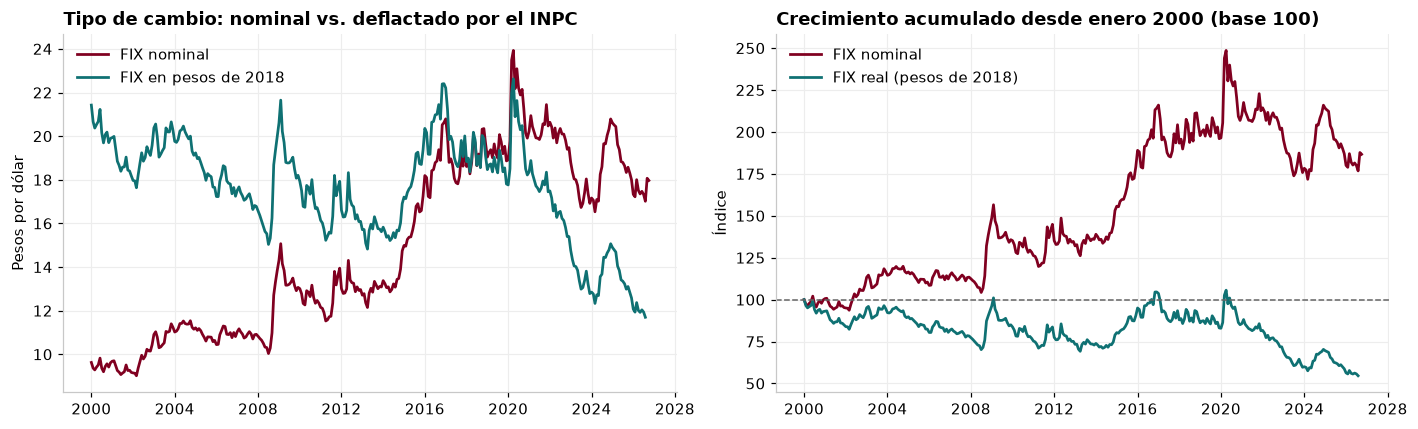

Enero 2000 → Oct 2026
  Depreciación NOMINAL :   9.63 →  17.97  (+86.7%)
  Depreciación REAL    :  21.42 →  11.70  (-45.4%)

→ Buena parte de la depreciación nominal es simplemente inflación mexicana.


In [17]:
# ─── Aplicación 2: serie nominal → real ───────────────────────────────────────
fix_real = sie.deflactar(df['FIX'], inpc).dropna()   # FIX en pesos de 2018 (INPC / 100)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(df.index, df['FIX'], color=C['guinda'], lw=1.8, label='FIX nominal')
ax[0].plot(fix_real.index, fix_real, color=C['teal'], lw=1.8,
           label='FIX en pesos de 2018')
ax[0].set_title('Tipo de cambio: nominal vs. deflactado por el INPC')
ax[0].set_ylabel('Pesos por dólar'); ax[0].legend()

# Índices base 100 para comparar el crecimiento acumulado
ax[1].plot(sie.indice_base(df['FIX'], '2000-01-01'), color=C['guinda'], lw=1.8,
           label='FIX nominal')
ax[1].plot(sie.indice_base(fix_real, '2000-01-01'), color=C['teal'], lw=1.8,
           label='FIX real (pesos de 2018)')
ax[1].axhline(100, color=C['gris'], ls='--', lw=1)
ax[1].set_title('Crecimiento acumulado desde enero 2000 (base 100)')
ax[1].set_ylabel('Índice'); ax[1].legend()

plt.tight_layout(); plt.show()

n0, n1 = sie.valor_en(df['FIX'], '2000-01-01'), df['FIX'].dropna().iloc[-1]
r0, r1 = sie.valor_en(fix_real, '2000-01-01'),  fix_real.iloc[-1]
print(f'Enero 2000 → {df.index[-1].strftime("%b %Y")}')
print(f'  Depreciación NOMINAL : {n0:6.2f} → {n1:6.2f}  ({(n1/n0-1)*100:+.1f}%)')
print(f'  Depreciación REAL    : {r0:6.2f} → {r1:6.2f}  ({(r1/r0-1)*100:+.1f}%)')
print('\n→ Buena parte de la depreciación nominal es simplemente inflación mexicana.')

> **Honestidad metodológica.** Lo que acabamos de calcular **no es** el tipo de cambio real
> bilateral. El TCR correcto es
> $$\text{TCR}_t = \frac{E_t \cdot P^{*}_t}{P_t}$$
> e incorpora también los precios **externos** $P^*$ (el CPI de Estados Unidos). Al deflactar
> solo por el INPC estamos suponiendo implícitamente que los precios en EE.UU. no cambian, lo
> cual es falso. Es un ejercicio válido para ilustrar la mecánica de deflactar, pero
> **no lo reportes como TCR**. Este tipo de precisión es exactamente lo que distingue un
> trabajo de seminario bien hecho de uno que "corrió el código".

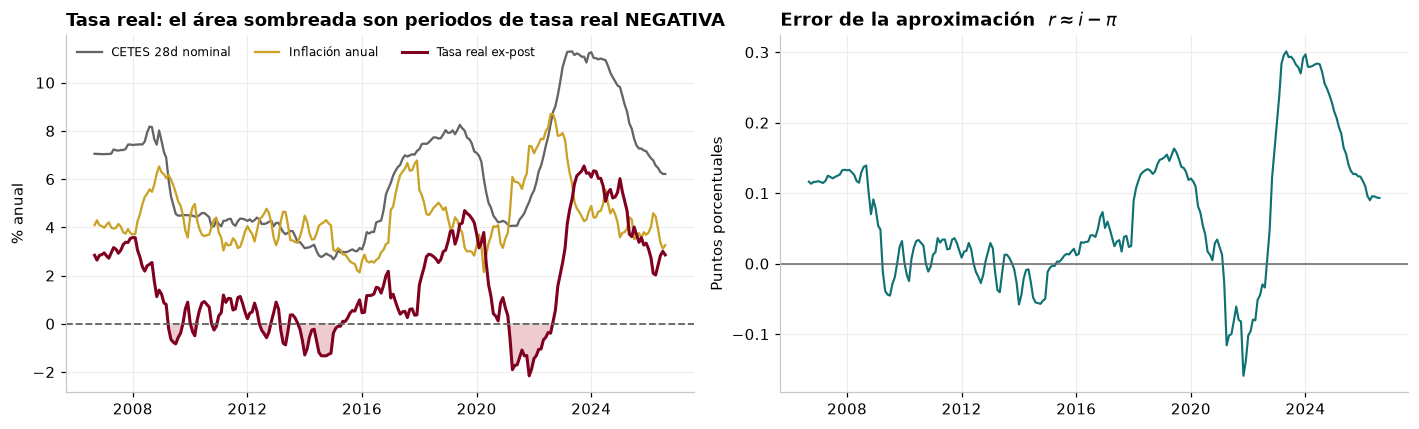

Meses con tasa real negativa: 22.9% de la muestra
Error medio de la aproximación i − π: 0.0682 pp
Error máximo                        : 0.3012 pp

→ La aproximación es buena con inflación baja, pero se degrada justo cuando
  la inflación es alta, que es cuando más importa acertar.


,Nominal (Cetes 28d),Inflación anual,Real exacta,Real aproximada,Error aprox (pp)
fecha,,,,,
2026-05-01,6.4650,3.9389,2.4303,2.5261,0.0957
2026-06-01,6.2940,3.3660,2.8327,2.9280,0.0953
2026-07-01,6.2175,3.1176,3.0061,3.0999,0.0937
2026-08-01,6.2125,3.2619,2.8574,2.9506,0.0932


In [18]:
# ─── Aplicación 3: tasa de interés real (Fisher) ──────────────────────────────
infl_anual = sie.variacion_anual(inpc).dropna()

fisher = pd.DataFrame({
    'Nominal (Cetes 28d)': df['Cetes28'],
    'Inflación anual'    : infl_anual,
}).dropna()

# Exacta:      (1+i)/(1+pi) - 1        Aproximada:  i - pi
fisher['Real exacta']     = sie.tasa_real(fisher['Nominal (Cetes 28d)'], fisher['Inflación anual'])
fisher['Real aproximada'] = sie.tasa_real(fisher['Nominal (Cetes 28d)'], fisher['Inflación anual'],
                                          exacta=False)
fisher['Error aprox (pp)'] = fisher['Real aproximada'] - fisher['Real exacta']

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(fisher.index, fisher['Nominal (Cetes 28d)'], color=C['gris'], lw=1.5,
           label='CETES 28d nominal')
ax[0].plot(fisher.index, fisher['Inflación anual'], color=C['ocre'], lw=1.5,
           label='Inflación anual')
ax[0].plot(fisher.index, fisher['Real exacta'], color=C['guinda'], lw=2,
           label='Tasa real ex-post')
ax[0].axhline(0, color=C['gris'], ls='--', lw=1.2)
ax[0].fill_between(fisher.index, fisher['Real exacta'], 0,
                   where=fisher['Real exacta'] < 0, color=C['rosa'], alpha=.45)
ax[0].set_title('Tasa real: el área sombreada son periodos de tasa real NEGATIVA')
ax[0].set_ylabel('% anual'); ax[0].legend(ncols=3, fontsize=8)

ax[1].plot(fisher.index, fisher['Error aprox (pp)'], color=C['teal'], lw=1.4)
ax[1].axhline(0, color=C['gris'], lw=1)
ax[1].set_title('Error de la aproximación  $r \\approx i - \\pi$')
ax[1].set_ylabel('Puntos porcentuales')

plt.tight_layout(); plt.show()

neg = (fisher['Real exacta'] < 0).mean() * 100
print(f'Meses con tasa real negativa: {neg:.1f}% de la muestra')
print(f'Error medio de la aproximación i − π: {fisher["Error aprox (pp)"].mean():.4f} pp')
print(f'Error máximo                        : {fisher["Error aprox (pp)"].abs().max():.4f} pp')
print('\n→ La aproximación es buena con inflación baja, pero se degrada justo cuando')
print('  la inflación es alta, que es cuando más importa acertar.')
display(fisher.tail(4))

---
## 8. Transformación 5 — Estandarización y normalización

### Qué hacen

| Nombre | Fórmula | Rango resultante | Sensible a atípicos |
|---|---|---|---|
| **Estandarización** ($z$-score) | $z_t=\dfrac{x_t-\bar{x}}{s_x}$ | $\mathbb{R}$, media 0, desv. 1 | Sí (usa media y desv.) |
| **Min–max** | $\dfrac{x_t-\min}{\max-\min}$ | $[0,1]$ | **Muchísimo** (usa los extremos) |
| **Escalamiento robusto** | $\dfrac{x_t-\text{mediana}}{\text{RIC}}$ | $\mathbb{R}$ | No (usa cuantiles) |

### Por qué las aplico

Para **poner en la misma unidad** variables con escalas incomparables. Es indispensable en:
métodos de regularización (Ridge, LASSO), PCA, *clustering*, redes neuronales, y cualquier
técnica basada en distancias o en penalizar coeficientes.

### Lo que NO hacen — y aquí es donde casi todos se equivocan

Las tres son transformaciones **afines**: $x \mapsto a + bx$. Por lo tanto:

- **No cambian la forma de la distribución.** Una serie sesgada sigue sesgada; una leptocúrtica
  sigue leptocúrtica. La curtosis y el sesgo son invariantes.
- **No eliminan la tendencia.** Una caminata aleatoria estandarizada sigue siendo una caminata
  aleatoria.
- **No inducen estacionariedad.** Lo demostramos formalmente abajo y empíricamente en la §11.

**Demostración.** Sea $y_t = \alpha + \delta t + u_t$ con $\delta \neq 0$. Entonces
$$z_t = \frac{y_t - \bar{y}}{s_y} = \frac{\alpha + \delta t + u_t - \bar{y}}{s_y}
      = \underbrace{\frac{\alpha-\bar{y}}{s_y}}_{\text{constante}}
      + \underbrace{\frac{\delta}{s_y}}_{\neq\,0} t + \frac{u_t}{s_y}$$
El término en $t$ **sigue ahí**, solo con pendiente reescalada. $E(z_t)$ sigue dependiendo de
$t$: la serie sigue siendo no estacionaria en media.

### 8.0 Desglose de las fórmulas

**El $z$-score, término por término.**

$$z_t = \frac{x_t - \bar{x}}{s_x}$$

- El numerador $x_t - \bar{x}$ **centra**: mide la distancia al promedio, en las unidades
  originales. Su promedio es cero por construcción, porque
  $\sum_t (x_t - \bar{x}) = \sum_t x_t - n\bar{x} = 0$.
- El denominador $s_x$ **reescala**: convierte esa distancia a "número de desviaciones
  estándar". El resultado ya no tiene unidades.

Verificamos las dos propiedades usando que $\bar x$ y $s_x$ son constantes:

$$E(z) = \frac{E(x) - \bar{x}}{s_x} = 0
\qquad\qquad
\operatorname{Var}(z) = \frac{\operatorname{Var}(x)}{s_x^{2}} = 1$$

**La clave: es una transformación afín.** Reescribiendo,

$$z_t = \underbrace{\left(-\frac{\bar{x}}{s_x}\right)}_{a}
      + \underbrace{\left(\frac{1}{s_x}\right)}_{b} x_t
\qquad\text{con } b > 0$$

Y min–max también lo es:

$$x'_t = \frac{x_t - \min}{\max-\min}
       = \underbrace{\left(\frac{-\min}{\max-\min}\right)}_{a}
       + \underbrace{\left(\frac{1}{\max-\min}\right)}_{b} x_t$$

**De ahí sale todo lo demás.** Como el sesgo y la curtosis son momentos **estandarizados**
—se dividen entre $\sigma^3$ y $\sigma^4$ respectivamente—, cualquier factor $b$ se cancela:

$$\text{Sesgo}(a+bx) = \frac{E[(a+bx - a - b\mu)^3]}{(b\sigma)^3}
= \frac{b^3 E[(x-\mu)^3]}{b^3\sigma^3} = \text{Sesgo}(x)$$

**La forma de la distribución no cambia. Nunca.** Escalar no vuelve normal a una serie
sesgada, no le quita las colas pesadas y no le quita la tendencia.

**Escalamiento a un rango arbitrario $[a,b]$.** Primero se lleva a $[0,1]$ y después se estira:

$$x'_t = a + (b-a)\cdot\frac{x_t - \min}{\max - \min}$$

**Escalamiento robusto.** Sustituye la media por la mediana y la desviación por el rango
intercuartílico $\text{RIC} = Q_3 - Q_1$:

$$x^{\text{rob}}_t = \frac{x_t - \text{mediana}(x)}{Q_3 - Q_1}$$

Sigue siendo afín, pero sus dos parámetros son **cuantiles**, y un cuantil no se mueve porque
una observación se vaya al infinito. Ahí está toda su ventaja.

### 8.1 Ejemplo numérico paso a paso

Trabajamos con la misma serie de cinco precios en todas las secciones, para que
puedas seguir el hilo de una transformación a otra:

$$P = \{100,\; 108,\; 102,\; 115,\; 110\}
\qquad t = 0, 1, 2, 3, 4$$

**Paso 1. La media.**

$$\bar{P} = \frac{100+108+102+115+110}{5} = \frac{535}{5} = 107$$

**Paso 2. Las desviaciones y sus cuadrados.**

| $t$ | $P_t$ | $P_t - \bar{P}$ | $(P_t-\bar{P})^2$ |
|---|---|---|---|
| 0 | 100 | $-7$ | 49 |
| 1 | 108 | $+1$ | 1 |
| 2 | 102 | $-5$ | 25 |
| 3 | 115 | $+8$ | 64 |
| 4 | 110 | $+3$ | 9 |
| | | **0** | **148** |

Nota que las desviaciones suman exactamente cero: esa es la comprobación de que la media
está bien calculada.

**Paso 3. La desviación estándar muestral** (dividiendo entre $n-1 = 4$):

$$s^2 = \frac{148}{4} = 37
\qquad\Longrightarrow\qquad
s = \sqrt{37} = 6.0828$$

**Paso 4. Los $z$-scores.**

| $t$ | Operación | $z_t$ |
|---|---|---|
| 0 | $-7/6.0828$ | $-1.1508$ |
| 1 | $+1/6.0828$ | $+0.1644$ |
| 2 | $-5/6.0828$ | $-0.8220$ |
| 3 | $+8/6.0828$ | $+1.3152$ |
| 4 | $+3/6.0828$ | $+0.4932$ |

Comprobación: suman cero y su desviación estándar muestral es exactamente 1.

**Paso 5. Min–max**, con $\min = 100$, $\max = 115$, rango $= 15$:

| $t$ | Operación | $x'_t$ |
|---|---|---|
| 0 | $(100-100)/15$ | $0.0000$ |
| 1 | $(108-100)/15$ | $0.5333$ |
| 2 | $(102-100)/15$ | $0.1333$ |
| 3 | $(115-100)/15$ | $1.0000$ |
| 4 | $(110-100)/15$ | $0.6667$ |

**Lo que hay que ver en las dos últimas tablas.** El orden de las cinco observaciones es
idéntico en $P$, en $z$ y en $x'$: $t_0 < t_2 < t_1 < t_4 < t_3$ en las tres. Las tres columnas
son **la misma información** contada en tres unidades distintas. Por eso ninguna de ellas puede
arreglar un problema de estacionariedad: no hay nada nuevo ahí.

In [19]:
# Verificación del ejemplo a mano (celda autocontenida)
P = pd.Series([100., 108., 102., 115., 110.], index=[f't{i}' for i in range(5)])

media = P.mean()
desv  = P - media
s     = np.sqrt((desv**2).sum() / (len(P) - 1))     # n-1, como en el desglose

ej8 = pd.DataFrame({
    'P_t'            : P,
    'P_t - media'    : desv,
    '(P_t - media)^2': desv**2,
    'z-score'        : desv / s,
    'min-max'        : (P - P.min()) / (P.max() - P.min()),
    'robusto'        : (P - P.median()) / (P.quantile(.75) - P.quantile(.25)),
})
print('Ejemplo numérico de la sección 8.1')
print(f'  media = {media:.4f}   suma de cuadrados = {(desv**2).sum():.4f}   '
      f'varianza = {(desv**2).sum()/(len(P)-1):.4f}   s = {s:.4f}\n')
display(ej8.style.format('{:,.4f}'))

# Comprobaciones del desglose
assert abs(desv.sum()) < 1e-12
assert abs(ej8['z-score'].mean()) < 1e-12
assert abs(ej8['z-score'].std(ddof=1) - 1) < 1e-12
assert abs(s - np.sqrt(37)) < 1e-12
print('OK  Las desviaciones suman 0; el z-score tiene media 0 y desviación 1;')
print(f'    s = raíz de 37 = {np.sqrt(37):.6f}\n')

# El resultado central: sesgo y curtosis NO cambian
print(f'{"":14s}{"Sesgo":>12s}{"Curtosis":>12s}')
for etq in ['P_t', 'z-score', 'min-max', 'robusto']:
    print(f'{etq:14s}{ej8[etq].skew():12.6f}{ej8[etq].kurt():12.6f}')
print('\nOK  Idénticos hasta el último decimal: la FORMA de la distribución')
print('    es invariante a cualquier transformación afín.\n')

# Y el orden de las observaciones tampoco cambia
ordenes = {c: list(ej8[c].rank().astype(int)) for c in ['P_t', 'z-score', 'min-max', 'robusto']}
for c, o in ordenes.items():
    print(f'  Rango de cada observación en {c:9s}: {o}')
assert len({tuple(o) for o in ordenes.values()}) == 1
print('\nOK  El mismo orden en las cuatro columnas: es la misma información.')

Ejemplo numérico de la sección 8.1
  media = 107.0000   suma de cuadrados = 148.0000   varianza = 37.0000   s = 6.0828



,P_t,P_t - media,(P_t - media)^2,z-score,min-max,robusto
t0,100.0000,-7.0000,49.0000,-1.1508,0.0000,-1.0000
t1,108.0000,1.0000,1.0000,0.1644,0.5333,0.0000
t2,102.0000,-5.0000,25.0000,-0.8220,0.1333,-0.7500
t3,115.0000,8.0000,64.0000,1.3152,1.0000,0.8750
t4,110.0000,3.0000,9.0000,0.4932,0.6667,0.2500


OK  Las desviaciones suman 0; el z-score tiene media 0 y desviación 1;
    s = raíz de 37 = 6.082763

                     Sesgo    Curtosis
P_t               0.133296   -1.422206
z-score           0.133296   -1.422206
min-max           0.133296   -1.422206
robusto           0.133296   -1.422206

OK  Idénticos hasta el último decimal: la FORMA de la distribución
    es invariante a cualquier transformación afín.

  Rango de cada observación en P_t      : [1, 3, 2, 5, 4]
  Rango de cada observación en z-score  : [1, 3, 2, 5, 4]
  Rango de cada observación en min-max  : [1, 3, 2, 5, 4]
  Rango de cada observación en robusto  : [1, 3, 2, 5, 4]

OK  El mismo orden en las cuatro columnas: es la misma información.


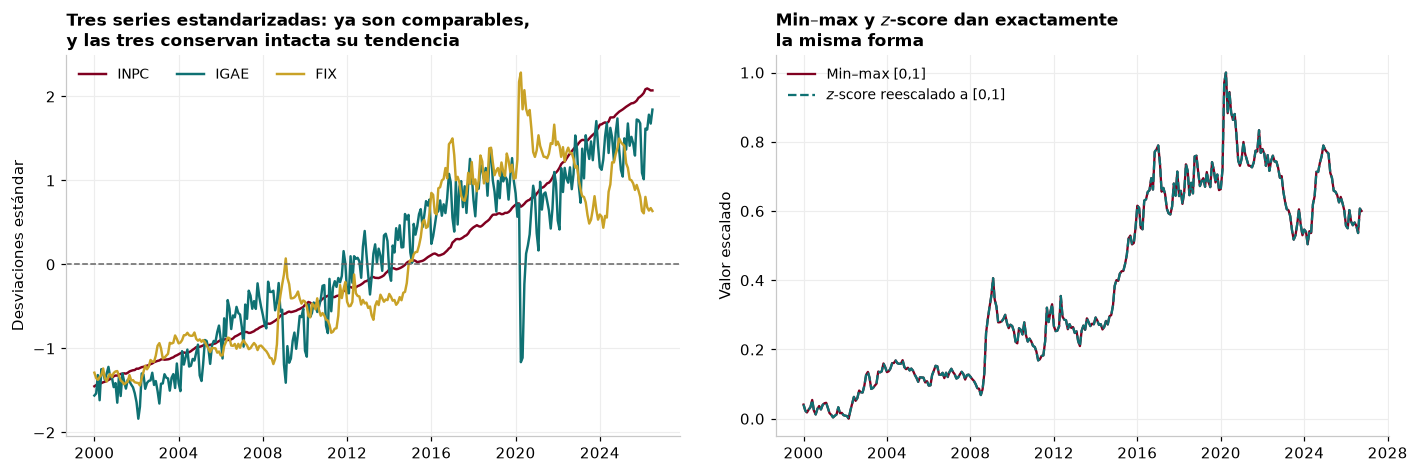

Momentos de la serie del FIX antes y después de sie.estandarizar:

                    Original     z-score     Min-max
Media                14.7845      0.0000      0.3868
Desv. est.            4.0022      1.0000      0.2684
Sesgo                 0.2422      0.2422      0.2422
Curtosis             -1.3943     -1.3943     -1.3943

→ Media y desviación cambian por construcción. SESGO Y CURTOSIS NO CAMBIAN:
  la forma de la distribución es exactamente la misma.


In [20]:
escaladas = sie.estandarizar(df[['INPC', 'IGAE', 'FIX']]).dropna()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

for col, color in zip(escaladas.columns, [C['guinda'], C['teal'], C['ocre']]):
    ax[0].plot(escaladas.index, escaladas[col], color=color, lw=1.6, label=col)
ax[0].axhline(0, color=C['gris'], ls='--', lw=1)
# Títulos en dos renglones: con titlelocation='left' un título largo se sale
# del ancho de su propio eje e invade el panel vecino.
ax[0].set_title('Tres series estandarizadas: ya son comparables,\n'
                'y las tres conservan intacta su tendencia', fontsize=11)
ax[0].set_ylabel('Desviaciones estándar')
ax[0].legend(ncols=3, loc='upper left', fontsize=9)

fix_s = df['FIX'].dropna()
ax[1].plot(sie.min_max(fix_s), color=C['guinda'], lw=1.5, label='Min–max [0,1]')
ax[1].plot(sie.estandarizar(fix_s).pipe(lambda s: (s - s.min())/(s.max()-s.min())),
           color=C['teal'], lw=1.5, ls='--', label='$z$-score reescalado a [0,1]')
ax[1].set_title('Min–max y $z$-score dan exactamente\nla misma forma', fontsize=11)
ax[1].set_ylabel('Valor escalado')
ax[1].legend(loc='upper left', fontsize=9)

# w_pad separa los paneles; el título de dos renglones ya cabe en su eje.
plt.tight_layout(w_pad=2.5)
plt.show()

# Los momentos que NO cambian
orig = df['FIX'].dropna()
print('Momentos de la serie del FIX antes y después de sie.estandarizar:\n')
print(f'{"":16s}{"Original":>12s}{"z-score":>12s}{"Min-max":>12s}')
for nombre, f in [('Media', lambda s: s.mean()), ('Desv. est.', lambda s: s.std()),
                  ('Sesgo', lambda s: s.skew()), ('Curtosis', lambda s: s.kurt())]:
    print(f'{nombre:16s}{f(orig):12.4f}{f(sie.estandarizar(orig)):12.4f}{f(sie.min_max(orig)):12.4f}')
print('\n→ Media y desviación cambian por construcción. SESGO Y CURTOSIS NO CAMBIAN:')
print('  la forma de la distribución es exactamente la misma.')

### 8.1 Sensibilidad a valores atípicos

Introducimos **un solo** dato extremo y observamos qué le pasa a cada método. El min–max
colapsa: como su denominador es el rango, un outlier comprime todo el resto de la serie hacia
cero. El escalamiento robusto ni se inmuta.

In [21]:
base_s = df['FIX'].dropna().copy()
con_outlier = base_s.copy()
con_outlier.iloc[len(con_outlier)//2] = base_s.max() * 3   # un choque artificial

comp_out = pd.DataFrame({
    'z-score sin outlier'  : sie.estandarizar(base_s).describe(),
    'z-score con outlier'  : sie.estandarizar(con_outlier).describe(),
    'min-max sin outlier'  : sie.min_max(base_s).describe(),
    'min-max con outlier'  : sie.min_max(con_outlier).describe(),
    'robusto sin outlier'  : sie.escalar_robusto(base_s).describe(),
    'robusto con outlier'  : sie.escalar_robusto(con_outlier).describe(),
}).T[['mean', 'std', '50%', 'max']]
comp_out.columns = ['Media', 'Desv. est.', 'Mediana', 'Máximo']
display(comp_out.style.format('{:,.4f}'))

print('Efecto de UN solo dato atípico sobre el rango ocupado por el 99% de los datos:')
for nombre, f in [('z-score', sie.estandarizar), ('min-max', sie.min_max), ('robusto', sie.escalar_robusto)]:
    a = f(base_s).quantile(.99) - f(base_s).quantile(.01)
    b = f(con_outlier).quantile(.99) - f(con_outlier).quantile(.01)
    print(f'  {nombre:9s}: {a:7.4f} → {b:7.4f}   (se comprimió {(1-b/a)*100:5.1f}%)')

,Media,Desv. est.,Mediana,Máximo
z-score sin outlier,0.0000,1.0000,-0.3713,2.2847
z-score con outlier,0.0000,1.0000,-0.3227,11.1224
min-max sin outlier,0.3868,0.2684,0.2872,1.0000
min-max con outlier,0.0948,0.0814,0.0685,1.0000
robusto sin outlier,0.1922,0.5177,0.0000,1.3750
robusto con outlier,0.2128,0.6592,0.0000,7.5452


Efecto de UN solo dato atípico sobre el rango ocupado por el 99% de los datos:
  z-score  :  3.2618 →  2.6938   (se comprimió  17.4%)
  min-max  :  0.8754 →  0.2192   (se comprimió  75.0%)
  robusto  :  1.6886 →  1.7759   (se comprimió  -5.2%)


### 8.2 Fuga de información (*data leakage*)

Este es un error silencioso y grave. Si calculas la media y la desviación con **toda** la
muestra y después separas entrenamiento y prueba, los parámetros del escalador ya vieron el
futuro. Tu modelo tendrá un desempeño fuera de muestra artificialmente bueno que **no se
reproduce en producción**.

**Regla:** los parámetros de cualquier transformación se estiman **solo con el conjunto de
entrenamiento** y se aplican tal cual al de prueba. Aunque eso implique que el conjunto de
prueba se salga del rango $[0,1]$ — y se sale, como veremos.

Corte: 2020-01-01  |  entrenamiento 241 obs, prueba 81 obs

                                           Media     Desv.
Prueba escalada CON fuga (incorrecto)     1.1299    0.4217
Prueba escalada SIN fuga (correcto)       1.8011    0.5031

Min–max ajustado solo con entrenamiento:
  Rango del conjunto de prueba: [0.6383, 1.2665]
  12.3% de las observaciones de prueba caen FUERA de [0,1]
  → Esto NO es un error: es la señal honesta de que el futuro salió del rango histórico.
    Forzarlo a [0,1] recortando valores destruiría precisamente esa información.


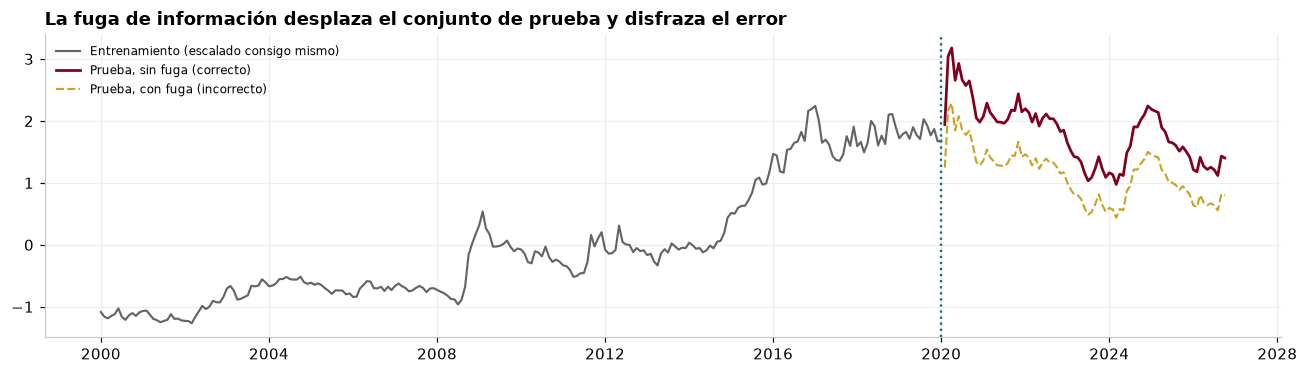

In [22]:
serie = df['FIX'].dropna()
corte = int(len(serie) * 0.75)
train, test = serie.iloc[:corte], serie.iloc[corte:]

# INCORRECTO: media y desviación calculadas con toda la muestra
test_mal = sie.estandarizar(test, referencia=serie)

# CORRECTO: media y desviación calculadas solo con entrenamiento
test_ok = sie.estandarizar(test, referencia=train)

test_mm_ok = sie.min_max(test, referencia=train)

print(f'Corte: {train.index[-1].date()}  |  entrenamiento {len(train)} obs, prueba {len(test)} obs\n')
print(f'{"":38s}{"Media":>10s}{"Desv.":>10s}')
print(f'{"Prueba escalada CON fuga (incorrecto)":38s}{test_mal.mean():10.4f}{test_mal.std():10.4f}')
print(f'{"Prueba escalada SIN fuga (correcto)":38s}{test_ok.mean():10.4f}{test_ok.std():10.4f}')

print(f'\nMin–max ajustado solo con entrenamiento:')
print(f'  Rango del conjunto de prueba: [{test_mm_ok.min():.4f}, {test_mm_ok.max():.4f}]')
fuera = ((test_mm_ok < 0) | (test_mm_ok > 1)).mean() * 100
print(f'  {fuera:.1f}% de las observaciones de prueba caen FUERA de [0,1]')
print('  → Esto NO es un error: es la señal honesta de que el futuro salió del rango histórico.')
print('    Forzarlo a [0,1] recortando valores destruiría precisamente esa información.')

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(sie.estandarizar(train).index, sie.estandarizar(train), color=C['gris'], lw=1.4,
        label='Entrenamiento (escalado consigo mismo)')
ax.plot(test_ok.index, test_ok, color=C['guinda'], lw=1.8,
        label='Prueba, sin fuga (correcto)')
ax.plot(test_mal.index, test_mal, color=C['ocre'], lw=1.4, ls='--',
        label='Prueba, con fuga (incorrecto)')
ax.axvline(train.index[-1], color=C['teal'], ls=':', lw=1.5)
ax.set_title('La fuga de información desplaza el conjunto de prueba y disfraza el error')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 9. Transformación 6 — Logaritmos y rendimientos

### Qué hace el logaritmo

Convierte relaciones **multiplicativas en aditivas** y crecimiento exponencial en lineal.
A diferencia de todo lo de la §8, el logaritmo **no es afín**: sí cambia la forma de la
distribución y sí estabiliza la varianza.

### Por qué lo aplico

1. **Estabilizar la varianza.** Si la volatilidad crece con el nivel de la serie
   (heterocedasticidad multiplicativa), el log la estabiliza.
2. **Interpretación como elasticidad.** En $\ln y = \alpha + \beta \ln x + u$, $\beta$ es
   directamente la elasticidad de $y$ respecto a $x$.
3. **Aditividad temporal.** $\sum_{t} r_t = \ln(P_T/P_0)$ exactamente. Con rendimientos
   simples esa suma no significa nada.

### Su límite

No está definido para valores $\le 0$. Sirve para precios, índices y niveles positivos; **no**
sirve para rendimientos, saldos netos o flujos que pueden ser negativos.

### 9.0 Desglose: por qué el log-log da elasticidades

Partimos del modelo

$$\ln y = \alpha + \beta \ln x + u$$

y derivamos respecto a $\ln x$:

$$\frac{d \ln y}{d \ln x} = \beta$$

Ahora usamos que la derivada del logaritmo es el cambio **relativo**, porque
$d\ln y = dy / y$:

$$\beta = \frac{d\ln y}{d\ln x} = \frac{dy/y}{dx/x}
= \frac{\text{cambio porcentual en } y}{\text{cambio porcentual en } x}$$

Eso es exactamente la definición de **elasticidad**. El coeficiente se lee directo, sin
transformar nada y sin depender de las unidades: da igual si $x$ está en pesos o en miles de
pesos.

**Pero ojo con la lectura exacta.** Decir "si $x$ sube 10%, $y$ sube $10\beta$ por ciento" es
una aproximación. El resultado exacto es multiplicativo: si $x$ se multiplica por $c$, entonces
$y$ se multiplica por $c^{\beta}$.

**Los otros dos casos**, para tenerlos juntos:

| Modelo | Coeficiente $\beta$ se lee como |
|---|---|
| $y = \alpha + \beta x$ (lin–lin) | Si $x$ sube 1 **unidad**, $y$ sube $\beta$ **unidades** |
| $\ln y = \alpha + \beta x$ (log–lin) | Si $x$ sube 1 **unidad**, $y$ sube $100\beta$ **por ciento** |
| $y = \alpha + \beta \ln x$ (lin–log) | Si $x$ sube 1%, $y$ sube $\beta/100$ **unidades** |
| $\ln y = \alpha + \beta \ln x$ (log–log) | Si $x$ sube 1%, $y$ sube $\beta$ **por ciento** (elasticidad) |

### 9.1 Ejemplo numérico paso a paso

Supongamos que estimaste una demanda y obtuviste $\hat\beta = 0.8$ en un modelo log–log, y que
el precio sube $10\%$.

**Lectura aproximada** (la que casi todos usan):

$$\%\Delta y \approx \beta \times \%\Delta x = 0.8 \times 10\% = 8.0000\%$$

**Lectura exacta:**

$$\frac{y_{\text{nuevo}}}{y_{\text{viejo}}} = (1.10)^{0.8}
= e^{0.8 \times \ln 1.10} = e^{0.8 \times 0.095310} = e^{0.076248} = 1.079232$$

$$\%\Delta y = 7.9232\%$$

La diferencia es de $0.0768$ pp, despreciable aquí. Pero si el precio subiera $50\%$:

$$(1.50)^{0.8} = 1.383288 \;\Rightarrow\; +38.3288\%
\qquad\text{contra}\qquad 0.8\times 50\% = 40.0000\%$$

Ahora la brecha es de $1.67$ pp. **La misma regla de siempre:** con cambios pequeños las dos
lecturas coinciden; con cambios grandes hay que ser explícito sobre cuál se está reportando.

**Y la propiedad que ya vimos en la §5**, ahora leída al revés: la razón por la que se
puede sumar log-rendimientos es la misma por la que el log-log da elasticidades. En ambos
casos el logaritmo convierte una relación **multiplicativa** —capitalizar, escalar— en una
relación **aditiva**, que es la única que MCO sabe estimar.

In [23]:
# Verificación del ejemplo a mano (celda autocontenida)
beta = 0.8
print('Ejemplo numérico de la sección 9.1  (elasticidad estimada = 0.8)\n')
print(f'{"Cambio en x":>13s}{"Lectura aprox":>16s}{"Lectura exacta":>17s}{"Diferencia":>13s}')
for cambio in [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]:
    aprox  = beta * cambio * 100
    exacta = ((1 + cambio)**beta - 1) * 100
    print(f'{cambio*100:12.1f}%{aprox:15.4f}%{exacta:16.4f}%{aprox-exacta:12.4f} pp')

print('\nDesglose del caso de +10%:')
c = 0.10
print(f'  ln(1 + 0.10)                 = {np.log(1+c):.6f}')
print(f'  beta * ln(1.10) = 0.8 * ...  = {beta*np.log(1+c):.6f}')
print(f'  exp(0.076248)                = {np.exp(beta*np.log(1+c)):.6f}')
print(f'  -> y aumenta {((1+c)**beta - 1)*100:.4f} %, no {beta*c*100:.4f} %')

assert abs(((1.10)**0.8 - 1)*100 - 7.9232) < 1e-3
print('\nOK  La lectura exacta es multiplicativa: y se multiplica por (1+c)^beta.')

Ejemplo numérico de la sección 9.1  (elasticidad estimada = 0.8)

  Cambio en x   Lectura aprox   Lectura exacta   Diferencia
         1.0%         0.8000%          0.7992%      0.0008 pp
         5.0%         4.0000%          3.9804%      0.0196 pp
        10.0%         8.0000%          7.9230%      0.0770 pp
        25.0%        20.0000%         19.5441%      0.4559 pp
        50.0%        40.0000%         38.3162%      1.6838 pp
       100.0%        80.0000%         74.1101%      5.8899 pp

Desglose del caso de +10%:
  ln(1 + 0.10)                 = 0.095310
  beta * ln(1.10) = 0.8 * ...  = 0.076248
  exp(0.076248)                = 1.079230
  -> y aumenta 7.9230 %, no 8.0000 %

OK  La lectura exacta es multiplicativa: y se multiplica por (1+c)^beta.


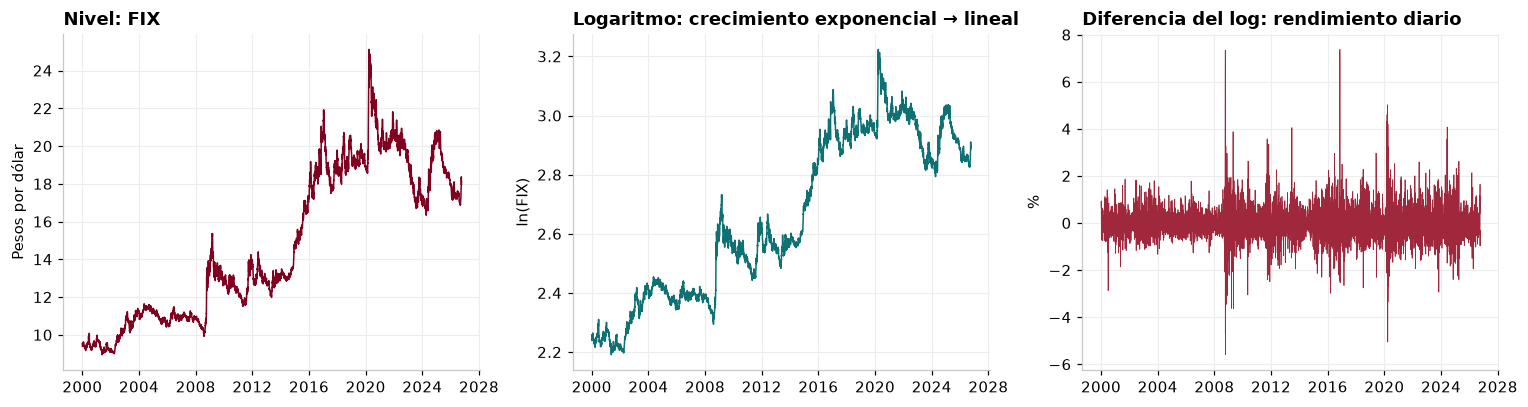

Aditividad temporal a lo largo de toda la muestra:
  Suma de rendimientos LOG      : 0.6483697531
  ln(P_final / P_inicial)       : 0.6483697531   ← idénticos
  Suma de rendimientos SIMPLES  : 0.8049348657   ← no significa nada
  Rendimiento total verdadero   : 0.9124205686

Estabilización de la varianza (ventana de 252 días):
  Coef. de variación del NIVEL — rango: [0.0101, 0.1484]
  Desv. est. del RENDIMIENTO   — rango: [0.3172, 1.3896]


In [24]:
fix_d = df_dia_raw['FIX'].dropna()

r_simple = fix_d.pct_change().dropna() * 100        # %
r_log    = np.log(fix_d).diff().dropna() * 100      # %

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))

ax[0].plot(fix_d.index, fix_d, color=C['guinda'], lw=1)
ax[0].set_title('Nivel: FIX')
ax[0].set_ylabel('Pesos por dólar')

ax[1].plot(fix_d.index, np.log(fix_d), color=C['teal'], lw=1)
ax[1].set_title('Logaritmo: crecimiento exponencial → lineal')
ax[1].set_ylabel('ln(FIX)')

ax[2].plot(r_log.index, r_log, color=C['guinda2'], lw=.5)
ax[2].set_title('Diferencia del log: rendimiento diario')
ax[2].set_ylabel('%')

plt.tight_layout(); plt.show()

# Aditividad temporal: la propiedad clave
acum_log = r_log.sum() / 100
acum_exacto = np.log(fix_d.iloc[-1] / fix_d.iloc[0])
acum_simple = (r_simple/100).sum()
print('Aditividad temporal a lo largo de toda la muestra:')
print(f'  Suma de rendimientos LOG      : {acum_log:.10f}')
print(f'  ln(P_final / P_inicial)       : {acum_exacto:.10f}   ← idénticos')
print(f'  Suma de rendimientos SIMPLES  : {acum_simple:.10f}   ← no significa nada')
print(f'  Rendimiento total verdadero   : {(fix_d.iloc[-1]/fix_d.iloc[0]-1):.10f}')

# Estabilización de la varianza
vol_nivel = fix_d.rolling(252).std() / fix_d.rolling(252).mean()
vol_ret   = r_log.rolling(252).std()
print(f'\nEstabilización de la varianza (ventana de 252 días):')
print(f'  Coef. de variación del NIVEL — rango: '
      f'[{vol_nivel.min():.4f}, {vol_nivel.max():.4f}]')
print(f'  Desv. est. del RENDIMIENTO   — rango: '
      f'[{vol_ret.min():.4f}, {vol_ret.max():.4f}]')

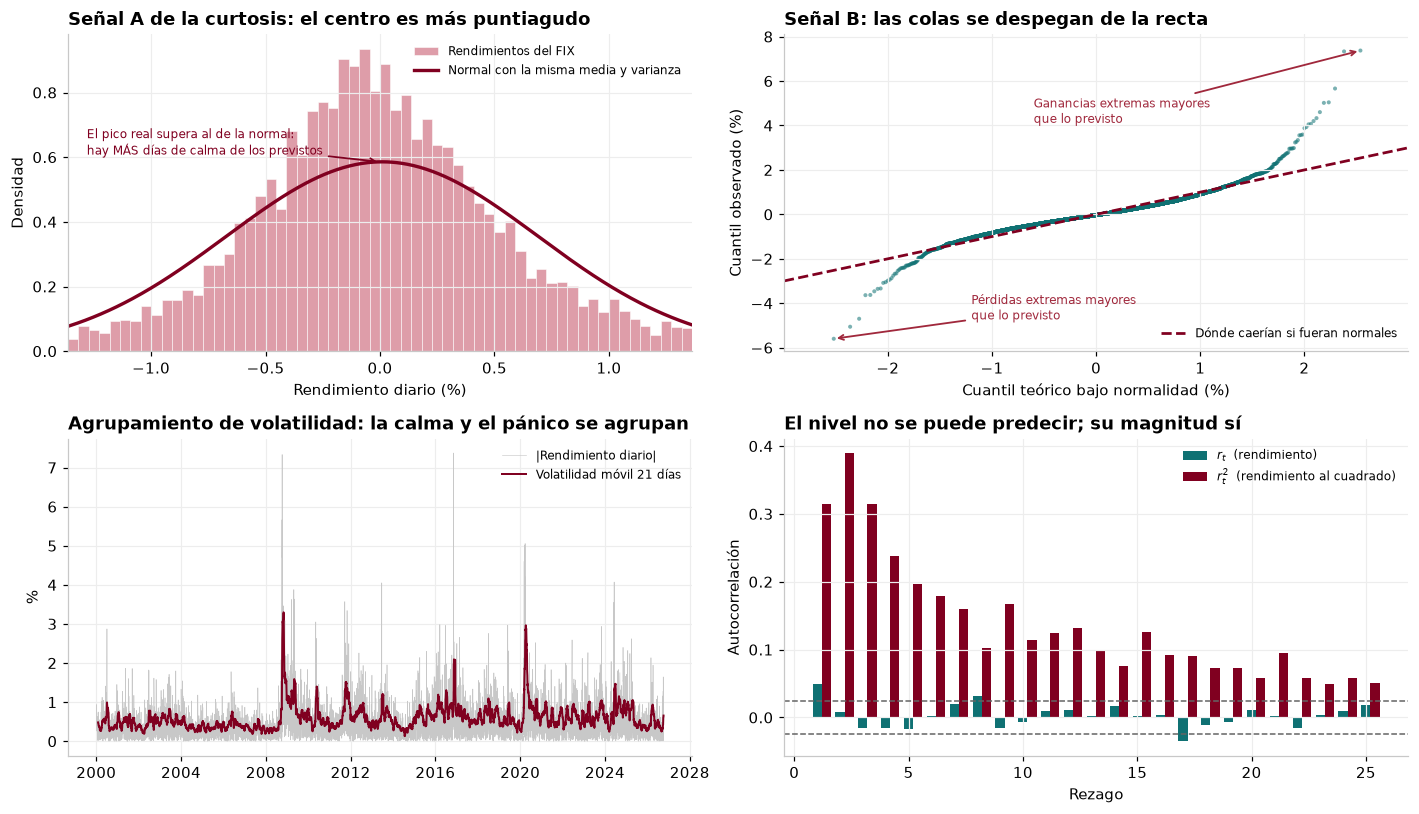

Curtosis en exceso: 10.29   (una normal tiene exactamente 0)

Qué significa ese número, en días de mercado observados:

    Movimiento   Observados   Esperados   Veces más   1 evento cada
-------------------------------------------------------------------
mas de 2 sigma          297      306.44        1.0x         22 días
mas de 3 sigma           88       18.18        4.8x          1 años
mas de 4 sigma           40        0.43       93.8x         63 años
mas de 5 sigma           21        0.00     5438.7x      6,922 años

El día más movido de la muestra: 7.37% = 10.8 desviaciones estándar.
Bajo normalidad, un día así ocurriría una vez cada 1.48e+24 años.
(La Tierra tiene 4.5e+09 años.) Y en esta muestra ocurrió.

Eso es la curtosis: no un numero abstracto, sino que los eventos extremos
son MUCHO mas frecuentes de lo que supondria un modelo gaussiano. Ignorarlo
significa subestimar el riesgo justo en los dias que importan.

Jarque-Bera: 30,334.5 (p = 0.000e+00) -> se RECHAZA normalidad

In [25]:
# Hechos estilizados que aparecen SOLO después de transformar a rendimientos
from scipy import stats
from statsmodels.tsa.stattools import acf

mu, sd = r_log.mean(), r_log.std()

fig, ax = plt.subplots(2, 2, figsize=(13, 7.5))
ax = ax.ravel()

# ─── 1. Curtosis, señal A: el CENTRO es más puntiagudo ────────────────────────
# Escala lineal y zoom a +/- 2 desviaciones: aquí vive el 95% de los datos.
lim_c = 2 * sd
ax[0].hist(r_log, bins=np.linspace(-lim_c, lim_c, 61), density=True,
           color=C['rosa'], alpha=.85, edgecolor='white', linewidth=.4,
           label='Rendimientos del FIX')
xc = np.linspace(-lim_c, lim_c, 400)
ax[0].plot(xc, stats.norm.pdf(xc, mu, sd), color=C['guinda'], lw=2.2,
           label='Normal con la misma media y varianza')
ax[0].set_xlim(-lim_c, lim_c)
ax[0].set_title('Señal A de la curtosis: el centro es más puntiagudo')
ax[0].set_xlabel('Rendimiento diario (%)'); ax[0].set_ylabel('Densidad')
ax[0].legend(fontsize=8, loc='upper right')
ax[0].annotate('El pico real supera al de la normal:\nhay MÁS días de calma de los previstos',
               xy=(0, stats.norm.pdf(0, mu, sd)), xycoords='data',
               xytext=(0.03, 0.62), textcoords='axes fraction',
               fontsize=8, color=C['guinda'],
               arrowprops=dict(arrowstyle='->', color=C['guinda'], lw=1.2))

# ─── 2. Curtosis, señal B: las COLAS son más gruesas ──────────────────────────
# Gráfica cuantil-cuantil: si los datos fueran normales, los puntos caerían
# sobre la recta. Se lee sin necesidad de escalas logarítmicas.
osm, osr = stats.probplot(r_log, dist='norm', fit=False)
teorico = mu + sd * osm
lo = min(teorico.min(), osr.min()); hi = max(teorico.max(), osr.max())

ax[1].scatter(teorico, osr, s=7, color=C['teal'], alpha=.55, edgecolor='none')
ax[1].plot([lo, hi], [lo, hi], color=C['guinda'], lw=1.8, ls='--',
           label='Dónde caerían si fueran normales')
# Los ejes se dejan independientes: el interés está en cuánto se despegan
# los puntos de la recta en los extremos, no en que el cuadro sea cuadrado.
mx = abs(teorico).max()
ax[1].set_xlim(-1.18 * mx, 1.18 * mx)
ax[1].set_ylim(min(osr.min(), -mx) * 1.10, max(osr.max(), mx) * 1.10)
ax[1].set_title('Señal B: las colas se despegan de la recta')
ax[1].set_xlabel('Cuantil teórico bajo normalidad (%)')
ax[1].set_ylabel('Cuantil observado (%)')
ax[1].legend(fontsize=8, loc='lower right')
ax[1].annotate('Pérdidas extremas mayores\nque lo previsto',
               xy=(teorico.min(), osr.min()), xycoords='data',
               xytext=(0.30, 0.10), textcoords='axes fraction',
               fontsize=8, color=C['guinda2'],
               arrowprops=dict(arrowstyle='->', color=C['guinda2'], lw=1.2))
ax[1].annotate('Ganancias extremas mayores\nque lo previsto',
               xy=(teorico.max(), osr.max()), xycoords='data',
               xytext=(0.40, 0.72), textcoords='axes fraction',
               fontsize=8, color=C['guinda2'],
               arrowprops=dict(arrowstyle='->', color=C['guinda2'], lw=1.2))

# ─── 3. Agrupamiento de volatilidad ───────────────────────────────────────────
ax[2].plot(r_log.index, r_log.abs(), color=C['gris_cl'], lw=.4,
           label='|Rendimiento diario|')
ax[2].plot(r_log.rolling(21).std().index, r_log.rolling(21).std(),
           color=C['guinda'], lw=1.3, label='Volatilidad móvil 21 días')
ax[2].set_title('Agrupamiento de volatilidad: la calma y el pánico se agrupan')
ax[2].set_ylabel('%'); ax[2].legend(fontsize=8)

# ─── 4. Autocorrelación ───────────────────────────────────────────────────────
lags = 25
ax[3].bar(np.arange(1, lags + 1), acf(r_log, nlags=lags)[1:], width=.4,
          color=C['teal'], label='$r_t$  (rendimiento)')
ax[3].bar(np.arange(1, lags + 1) + .4, acf(r_log**2, nlags=lags)[1:], width=.4,
          color=C['guinda'], label='$r_t^2$  (rendimiento al cuadrado)')
banda = 1.96 / np.sqrt(len(r_log))
ax[3].axhline(banda, color=C['gris'], ls='--', lw=1)
ax[3].axhline(-banda, color=C['gris'], ls='--', lw=1)
ax[3].set_title('El nivel no se puede predecir; su magnitud sí')
ax[3].set_xlabel('Rezago'); ax[3].set_ylabel('Autocorrelación')
ax[3].legend(fontsize=8)

plt.tight_layout(); plt.show()

# ─── La curtosis, traducida a días contados ───────────────────────────────────
# El número "curtosis = 10.3" no le dice nada a nadie. Contar días sí.
n = len(r_log)
print(f'Curtosis en exceso: {r_log.kurt():.2f}   (una normal tiene exactamente 0)\n')
print('Qué significa ese número, en días de mercado observados:\n')
print(f'{"Movimiento":>14s}{"Observados":>13s}{"Esperados":>12s}{"Veces más":>12s}'
      f'{"1 evento cada":>16s}')
print('-' * 67)
for k in [2, 3, 4, 5]:
    obs = int((r_log.abs() > k * sd).sum())
    prob = 2 * stats.norm.sf(k)
    esp = n * prob
    veces = obs / esp if esp > 0 else np.inf
    anios = 1 / (prob * 252)          # 252 días hábiles por año
    if anios < 1:
        periodo = f'{anios*252:,.0f} días'
    elif anios < 1e6:
        periodo = f'{anios:,.0f} años'
    else:
        periodo = f'{anios:.1e} años'
    print(f'{"mas de " + str(k) + " sigma":>14s}{obs:13,d}{esp:12.2f}{veces:11.1f}x'
          f'{periodo:>16s}')

peor = r_log.abs().max()
z_peor = peor / sd
prob_peor = 2 * stats.norm.sf(z_peor)
print(f'\nEl día más movido de la muestra: {peor:.2f}% = {z_peor:.1f} desviaciones estándar.')
if prob_peor > 0:
    anios_peor = 1 / (prob_peor * 252)
    print(f'Bajo normalidad, un día así ocurriría una vez cada {anios_peor:.2e} años.')
    print(f'(La Tierra tiene 4.5e+09 años.) Y en esta muestra ocurrió.')
print('\nEso es la curtosis: no un numero abstracto, sino que los eventos extremos')
print('son MUCHO mas frecuentes de lo que supondria un modelo gaussiano. Ignorarlo')
print('significa subestimar el riesgo justo en los dias que importan.')

jb, pjb = stats.jarque_bera(r_log)[:2]
veredicto = 'se RECHAZA normalidad' if pjb < 0.05 else 'no se rechaza normalidad'
print(f'\nJarque-Bera: {jb:,.1f} (p = {pjb:.3e}) -> {veredicto}')
print(f'Sesgo: {r_log.skew():.4f}   Curtosis en exceso: {r_log.kurt():.4f}')
print('\n-> Estos hechos estilizados NO son visibles en la serie de niveles.')
print('   La transformacion no solo "prepara" los datos: revela la estructura a modelar.')

---
## 10. ¿Cuál transformación uso? Árbol de decisión

La pregunta nunca es "¿qué transformación está de moda?" sino **"¿qué problema tengo?"**

| Si tu problema es… | Usa | Ejemplo del notebook |
|---|---|---|
| Series en unidades distintas que quiero graficar juntas | **Número índice** (§4) o $z$-score (§8) | INPC vs. IGAE vs. FIX |
| Comparar el crecimiento acumulado desde un punto | **Número índice base 100** (§4) | §4 |
| La variable de interés es el cambio, no el nivel | **Tasa de variación** (§5) | Inflación |
| La serie tiene tendencia / raíz unitaria | **Diferenciar** ($\Delta$ o $\Delta\ln$) (§5, §9) | §11 |
| La serie tiene patrón estacional fijo | **$\Delta_{12}$ o desestacionalizar** (§6) | IGAE |
| Comparo montos monetarios de años distintos | **Deflactar** (§7) | Poder adquisitivo |
| Tengo una tasa nominal y quiero la real | **Fisher** (§7) | CETES real |
| Voy a usar Ridge / LASSO / PCA / *clustering* | **Estandarizar** (§8) | §8 |
| Hay valores atípicos que dominan la escala | **Escalamiento robusto** (§8) | §8.1 |
| La volatilidad crece con el nivel | **Logaritmo** (§9) | FIX |
| Quiero elasticidades interpretables | **Log–log** (§9) | — |
| Necesito rendimientos agregables en el tiempo | **Log-rendimientos** (§9) | §9 |

### Reglas que no se negocian

1. **Documenta cada transformación.** Una serie sin su bitácora de transformaciones es
   irreproducible.
2. **El orden importa.** Deflactar y luego diferenciar ≠ diferenciar y luego deflactar.
   Regla general: primero unidades (deflactar, convertir moneda), después escala
   (índice, log), y al final estacionariedad (diferenciar).
3. **Las transformaciones afines no arreglan problemas de estacionariedad.** Nunca.
4. **Estima los parámetros del escalador solo con el entrenamiento.**
5. **Guarda siempre la serie original.** Toda transformación debe ser reversible o al menos
   auditable.

---
## 11. Verificación empírica: ¿cuál transformación SÍ induce estacionariedad?

Aquí está la justificación que le da sentido a todo lo anterior. Sometemos el mismo INPC,
transformado de nueve maneras distintas, a la prueba **Dickey–Fuller Aumentada**:

$$H_0:\ \text{la serie tiene raíz unitaria (no estacionaria)}$$
$$H_1:\ \text{la serie es estacionaria}$$

Se rechaza $H_0$ cuando el $p$-valor < 0.05.

**Predice antes de correr la celda:** ¿cuáles crees que van a resultar estacionarias?

In [26]:
serie_base = df['INPC'].dropna()

transformaciones = {
    '1. Nivel (sin transformar)'      : serie_base,
    '2. Índice base 100'              : sie.indice_base(serie_base, '2018-01-01'),
    '3. Estandarizada (z-score)'      : sie.estandarizar(serie_base),
    '4. Normalizada min–max'          : sie.min_max(serie_base),
    '5. Escalamiento robusto'         : sie.escalar_robusto(serie_base),
    '6. Logaritmo'                    : np.log(serie_base),
    '7. Primera diferencia  Δ'        : serie_base.diff(),
    '8. Diferencia log  Δln (tasa)'   : np.log(serie_base).diff(),
    '9. Diferencia estacional  Δ₁₂'   : serie_base.diff(12),
    '10. Δ de la tasa anual  ΔΔ₁₂ln'  : np.log(serie_base).diff(12).diff(),
}

# Una sola llamada aplica la prueba ADF (rezagos por AIC) a todo el diccionario
resultados = (sie.prueba_adf(transformaciones)
              .drop(columns='rezagos')
              .rename(columns={'estadistico' : 'Estadístico ADF',
                               'critico_5%'  : 'Valor crítico 5%',
                               'p_valor'     : 'p-valor',
                               'obs'         : 'Obs',
                               'estacionaria': '¿Estacionaria?'})
              .rename_axis('Transformación'))
resultados['¿Estacionaria?'] = resultados['¿Estacionaria?'].map({True: 'Sí', False: 'No'})

# ─── Estilo de la tabla ───────────────────────────────────────────────────────
# Se fija SIEMPRE el color del texto junto con el del fondo. Si solo se define
# el fondo, en el modo oscuro de Colab el texto sigue siendo claro y la celda
# queda ilegible (contraste ~1.1:1). Con ambos fijados el contraste es >8:1
# en cualquier tema.
VERDE_BG, VERDE_TXT = '#D8F0E2', '#0B4D2C'   # estacionaria
ROJO_BG,  ROJO_TXT  = '#F9DDE3', '#6E0A1F'   # no estacionaria


def resaltar(fila):
    es = fila['¿Estacionaria?'] == 'Sí'
    bg, txt = (VERDE_BG, VERDE_TXT) if es else (ROJO_BG, ROJO_TXT)
    return [f'background-color: {bg}; color: {txt};'] * len(fila)


def formato_p(p):
    '''Un p-valor de 1e-15 no debe mostrarse como 0.0000: parece un error.'''
    return '< 0.0001' if p < 1e-4 else f'{p:.4f}'


estilos = [
    # Encabezado: guinda con texto blanco
    {'selector': 'thead th',
     'props': [('background-color', '#800020'), ('color', '#FFFFFF'),
               ('font-weight', 'bold'), ('text-align', 'center'),
               ('padding', '8px 10px'), ('border', '1px solid #FFFFFF')]},
    # Columna de índice (nombres de las transformaciones)
    {'selector': 'tbody th',
     'props': [('background-color', '#F2F2F2'), ('color', '#1F1F1F'),
               ('font-weight', 'bold'), ('text-align', 'left'),
               ('padding', '6px 10px'), ('border', '1px solid #FFFFFF')]},
    {'selector': 'td',
     'props': [('text-align', 'right'), ('padding', '6px 10px'),
               ('border', '1px solid #FFFFFF'), ('font-variant-numeric', 'tabular-nums')]},
    {'selector': 'table',
     'props': [('border-collapse', 'collapse'), ('font-size', '13px')]},
]

tabla = (resultados.style
         .apply(resaltar, axis=1)
         .set_table_styles(estilos)
         .format({'Estadístico ADF': '{:.4f}',
                  'Valor crítico 5%': '{:.4f}',
                  'p-valor': formato_p,
                  'Obs': '{:,.0f}'})
         .set_properties(subset=['¿Estacionaria?'],
                         **{'font-weight': 'bold', 'text-align': 'center'})
         .set_caption('Prueba Dickey–Fuller Aumentada sobre el INPC, '
                      'bajo diez transformaciones distintas'))

display(tabla)

print(f'Estacionarias: {(resultados["¿Estacionaria?"] == "Sí").sum()} de {len(resultados)}')
print('Regla de decisión: se rechaza la raíz unitaria cuando el estadístico ADF')
print('es MENOR (más negativo) que el valor crítico al 5%.')

,Estadístico ADF,Valor crítico 5%,p-valor,Obs,¿Estacionaria?
Transformación,,,,,
1. Nivel (sin transformar),1.9039,-2.8710,0.9985,307,No
2. Índice base 100,1.9039,-2.8710,0.9985,307,No
3. Estandarizada (z-score),1.9039,-2.8710,0.9985,307,No
4. Normalizada min–max,1.9039,-2.8710,0.9985,307,No
5. Escalamiento robusto,1.9039,-2.8710,0.9985,307,No
6. Logaritmo,0.1481,-2.8710,0.9692,306,No
7. Primera diferencia Δ,-2.2235,-2.8712,0.1978,301,No
8. Diferencia log Δln (tasa),-3.6544,-2.8710,0.0048,307,Sí
9. Diferencia estacional Δ₁₂,-1.9239,-2.8714,0.3209,294,No


Estacionarias: 2 de 10
Regla de decisión: se rechaza la raíz unitaria cuando el estadístico ADF
es MENOR (más negativo) que el valor crítico al 5%.


### 11.1 Lee la tabla con cuidado — hay dos hallazgos

**Hallazgo 1: las filas 1 a 5 tienen el MISMO estadístico ADF.**

No es coincidencia ni error numérico. La regresión de Dickey–Fuller incluye una constante, y el
estadístico $t$ sobre el coeficiente autorregresivo es **invariante a transformaciones afines**
$x \mapsto a + bx$ con $b>0$. Indexar, estandarizar y normalizar son todas afines, así que
producen literalmente el mismo resultado.

> **La conclusión práctica es contundente:** si estandarizaste tu serie esperando volverla
> estacionaria, no lograste nada. Ni un poco. El estadístico es idéntico hasta el último decimal.

**Hallazgo 2: solo diferenciar funciona.**

El logaritmo (fila 6) tampoco es suficiente por sí solo —cambia el estadístico porque no es
afín, pero no elimina la raíz unitaria—. Las que sí funcionan son las que involucran
**diferenciación**: filas 7 a 10.

Esto conecta directamente con la $d$ del ARIMA$(p,d,q)$: $d$ es exactamente el número de
diferencias necesarias para llegar a la primera fila verde.

Comprobemos el hallazgo 1 numéricamente.

In [27]:
afines = ['1. Nivel (sin transformar)', '2. Índice base 100',
          '3. Estandarizada (z-score)', '4. Normalizada min–max',
          '5. Escalamiento robusto']

estadisticos = resultados.loc[afines, 'Estadístico ADF']
print('Estadístico ADF de las cinco transformaciones afines:\n')
for nombre, v in estadisticos.items():
    print(f'  {nombre:32s}  {v:.12f}')

print(f'\nRango entre el máximo y el mínimo: {estadisticos.max() - estadisticos.min():.2e}')
print('→ Cero, salvo error de redondeo numérico. Son la misma prueba.\n')

# Y ahora la misma comparación sobre una serie que SÍ es estacionaria de origen
print('Contraprueba — la tasa de inflación mensual (ya estacionaria):')
tasa = np.log(serie_base).diff().dropna()
for etiqueta, s in [('Sin escalar', tasa), ('Estandarizada', sie.estandarizar(tasa))]:
    est, p = sie.prueba_adf(s).iloc[0][['estadistico', 'p_valor']]
    print(f'  {etiqueta:16s} ADF = {est:8.4f}   p = {p:.6f}')
print('→ También idénticos. Escalar nunca cambia la conclusión sobre estacionariedad.')

Estadístico ADF de las cinco transformaciones afines:

  1. Nivel (sin transformar)        1.903886428922
  2. Índice base 100                1.903886428922
  3. Estandarizada (z-score)        1.903886428922
  4. Normalizada min–max            1.903886428922
  5. Escalamiento robusto           1.903886428922

Rango entre el máximo y el mínimo: 1.99e-13
→ Cero, salvo error de redondeo numérico. Son la misma prueba.

Contraprueba — la tasa de inflación mensual (ya estacionaria):
  Sin escalar      ADF =  -3.6544   p = 0.004801
  Estandarizada    ADF =  -3.6544   p = 0.004801
→ También idénticos. Escalar nunca cambia la conclusión sobre estacionariedad.


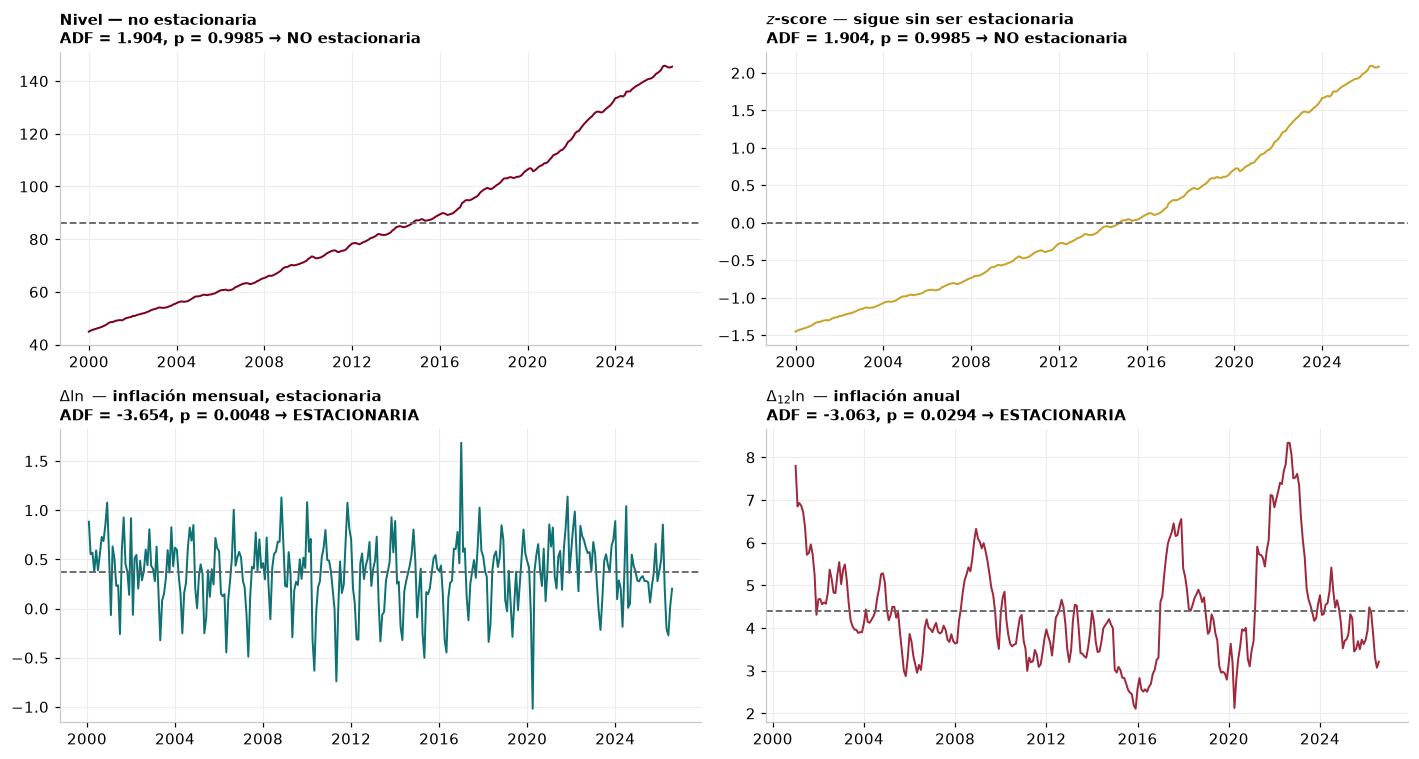

La línea punteada es la media muestral. Fíjate en los dos primeros paneles:
la serie cruza la media una sola vez. En los dos últimos la cruza constantemente:
eso es, visualmente, la reversión a la media que caracteriza a una serie estacionaria.


In [28]:
# Visualización del recorrido completo: de la serie cruda a la serie modelable
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
ax = ax.ravel()

paneles = [
    ('Nivel — no estacionaria',            serie_base,                       C['guinda']),
    ('$z$-score — sigue sin ser estacionaria', sie.estandarizar(serie_base),     C['ocre']),
    ('$\\Delta\\ln$ — inflación mensual, estacionaria', np.log(serie_base).diff()*100, C['teal']),
    ('$\\Delta_{12}\\ln$ — inflación anual', np.log(serie_base).diff(12)*100, C['guinda2']),
]

for a, (titulo, s, color) in zip(ax, paneles):
    s = s.dropna()
    a.plot(s.index, s, color=color, lw=1.3)
    a.axhline(s.mean(), color=C['gris'], ls='--', lw=1.2)
    est, p = sie.prueba_adf(s).iloc[0][['estadistico', 'p_valor']]
    veredicto = 'ESTACIONARIA' if p < .05 else 'NO estacionaria'
    a.set_title(f'{titulo}\nADF = {est:.3f}, p = {p:.4f} → {veredicto}', fontsize=10)

plt.tight_layout(); plt.show()

print('La línea punteada es la media muestral. Fíjate en los dos primeros paneles:')
print('la serie cruza la media una sola vez. En los dos últimos la cruza constantemente:')
print('eso es, visualmente, la reversión a la media que caracteriza a una serie estacionaria.')

---
## 12. Errores comunes y ejercicios

### 12.1 Los ocho errores que más veo

| # | Error | Por qué importa | Sección |
|---|-------|-----------------|---------|
| 1 | Estandarizar creyendo que induce estacionariedad | No hace absolutamente nada; el ADF es idéntico | §11 |
| 2 | Leer variación mes a mes de una serie estacional | Confunde el calendario con la economía | §6 |
| 3 | Comparar montos nominales de años distintos | Son unidades diferentes con el mismo nombre | §7 |
| 4 | Calcular el escalador con toda la muestra | Fuga de información; el error fuera de muestra se subestima | §8.2 |
| 5 | Promediar precios diarios para obtener el dato mensual | Subestima la volatilidad por construcción | §3.2 |
| 6 | Reportar $\Delta\ln$ como si fuera el cambio porcentual | Con variaciones grandes el error es de varios puntos | §5.1 |
| 7 | Sobrediferenciar "por si acaso" | Introduce una raíz unitaria en el componente MA e infla la varianza | §5 |
| 8 | Usar `pd.to_datetime` sin `dayfirst=True` con datos de Banxico | Desordena la serie en silencio, sin lanzar error | §2 |

### 12.2 Ejercicios

1. **Índices.** Construye un índice base 100 = enero 2020 para el FIX, el INPC y los CETES.
   ¿Cuál creció más desde el inicio de la pandemia? Justifica por qué indexar CETES
   (una tasa) es conceptualmente discutible.

2. **Estacionalidad.** Descompón el INPC con `seasonal_decompose`. ¿Tiene estacionalidad?
   ¿En qué meses? Relaciona el patrón con el calendario de precios administrados
   (electricidad de temporada cálida, colegiaturas).

3. **Deflactar.** Toma el salario mínimo general nominal (búscalo en el SIE o captúralo a mano)
   y deflátalo con el INPC. ¿Ha recuperado su poder adquisitivo de 1994?

4. **Fisher.** Repite el ejercicio de la tasa real usando la **inflación esperada** en lugar de
   la observada. ¿Por qué la tasa real *ex-ante* es la económicamente relevante para decidir
   una inversión, y la *ex-post* la que se puede calcular?

5. **Fuga de información.** Estima una regresión simple del FIX contra los CETES, primero
   estandarizando con toda la muestra y luego solo con el entrenamiento. Compara el
   $R^2$ fuera de muestra. ¿Cuánto se infla?

6. **Orden de las transformaciones.** Toma el FIX. Calcula (a) deflactar y luego diferenciar,
   y (b) diferenciar y luego deflactar. Grafícalas juntas. ¿Son iguales? ¿Cuál tiene
   interpretación económica?

7. **Sobrediferenciación.** Aplica $\Delta$ dos veces a la inflación mensual. Grafica la ACF y
   compara la varianza con la de una sola diferencia. Identifica los dos síntomas clásicos.

8. **Integrador.** Elige cualquier serie del SIE que no hayamos usado. Documenta en una tabla:
   frecuencia, unidad, si tiene estacionalidad, qué transformaciones aplicaste, en qué orden y
   con qué justificación, y el resultado del ADF antes y después.

---

### Referencias

- Banco de México. *API del Sistema de Información Económica (SIE)*.
  [Catálogo de series](https://www.banxico.org.mx/SieAPIRest/service/v1/doc/catalogoSeries)
- Brooks, C. (2019). *Introductory Econometrics for Finance*, 4ª ed. Cambridge University Press. Caps. 2 y 8.
- Enders, W. (2015). *Applied Econometric Time Series*, 4ª ed. Wiley. Cap. 4.
- Hyndman, R. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice*, 3ª ed.
  [otexts.com/fpp3](https://otexts.com/fpp3/) — Caps. 3 y 9.
- INEGI. *Índice Nacional de Precios al Consumidor: metodología y cambios de base*.
- Tsay, R. (2010). *Analysis of Financial Time Series*, 3ª ed. Wiley. Cap. 1.

---

*Ana Lorena Jiménez Preciado · Escuela Superior de Economía — IPN · Seminario · 2026*